# Pretrained PlasmidLM Analysis

This notebook evaluates pretrained PlasmidLM models by:
1. **Building a motif-based scoring metric** — aligning expected functional annotations against generated DNA via semi-global alignment
2. **Validating the scorer** on pUC19 (known ground truth) and real plasmids from the training set
3. **Testing pretrained model outputs** — generating sequences conditioned on annotation prompts and scoring them

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
! ls drive/MyDrive/plasmidgpt-v2-data/

motif_registry_combined_big.parquet  output			val
motif_registry_combined.parquet      outputs			vocab.json
motif_registry.json		     train
motif_registry.parquet		     training_pairs_v4.parquet


In [3]:
%%capture
! pip install transformers>=5.2.0
! pip install parasail 
! pip install Biopython

# Part 1: Motif-Based Scoring Metric

Load the motif registry — a database mapping annotation tokens (e.g. `<AMR_AMPICILLIN>`, `<ORI_COLE1>`) to their reference DNA/protein sequences.

In [4]:
import pandas as pd
import numpy as np
import parasail

#motifs = pd.read_parquet("drive/MyDrive/plasmidgpt-v2-data/motif_registry.parquet")
motifs = pd.read_parquet("drive/MyDrive/plasmidgpt-v2-data/motif_registry_combined_big.parquet")


motifs.head()

,uuid,token,category,features,plasmid_count,sseqid,db_source,seq_type,seq_len,sequence
0,d053544e-a84d-5811-8181-c761bd39e531,<AMR_AMPICILLIN>,AMR,"AmpR,ampR",99829,AmpR,snapgene,dna,861.0,ATGAGTATTCAACATTTCCGTGTCGCCCTTATTCCCTTTTTTGCGG...
1,d053544e-a84d-5811-8181-c761bd39e531,<AMR_AMPICILLIN>,AMR,"AmpR,ampR",99829,AmpR_(2),snapgene,dna,861.0,ATGAGTATTCAACATTTCCGTGTCGCCCTTATTCCCTTTTTTGCGG...
2,d053544e-a84d-5811-8181-c761bd39e531,<AMR_AMPICILLIN>,AMR,"AmpR,ampR",99829,AmpR_(3),snapgene,dna,861.0,ATGAGCATCCAACATTTTCGTGTCGCACTCATTCCCTTCTTTGCGG...
3,d053544e-a84d-5811-8181-c761bd39e531,<AMR_AMPICILLIN>,AMR,"AmpR,ampR",99829,AmpR_(4),snapgene,dna,861.0,ATGAGTATTCAACATTTCCGTGTCGCCCTTATTCCCTTTTTTGCGG...
4,d053544e-a84d-5811-8181-c761bd39e531,<AMR_AMPICILLIN>,AMR,"AmpR,ampR",99829,P12529,swissprot,protein,291.0,MTRSYIPLNSLRAFEAAARHLSFTRAAIELNVTHSAISQHVKSLEQ...


In [5]:
len(motifs)

660

## Scorer Implementation

### What this does

We evaluate generated plasmid sequences by aligning expected functional annotations (promoters, origins of replication, resistance genes, etc.) against the generated DNA using semi-global sequence alignment via [parasail](https://github.com/jeffdaily/parasail).

For each expected annotation token (e.g. `<PROM_AMPR>`, `<ORI_COLE1>`), the scorer:

1. Looks up all reference sequences for that token in our motif database (which contains both DNA and protein references from SnapGene, SwissProt, etc.)
2. Aligns each reference against the target plasmid using `sg_qx` semi-global alignment (query end-gaps free, reference end-gaps penalized) — this finds the motif anywhere within the target without letting the aligner skip parts of the motif
3. Parses the CIGAR string to extract true match/mismatch/gap counts and genomic coordinates
4. Deduplicates hits: first within each token (multiple DB variants), then across tokens (different annotations claiming the same region), using greedy NMS with IoU-based overlap detection
5. Computes a per-token quality score: `0.4 × pct_identity + 0.35 × coverage + 0.25 × norm_score`
6. Aggregates into a composite: `composite = quality × recall_penalty`, where quality is the geometric mean of found token scores raised to a sharpness exponent, and recall_penalty is a soft linear term that doesn't destroy the score when DB references are missing

### Composite score formula
```
quality       = geo_mean(found_token_scores) ^ sharpness
recall_penalty = recall_floor + (1 - recall_floor) × (found / expected)
composite      = quality × recall_penalty
```

Default parameters: `sharpness=2.0`, `recall_floor=0.5`, `norm_score_cap=5.0`.


In [6]:
import parasail
from Bio.Seq import Seq
import re
import math
from collections import defaultdict


class MotifScorer:
    def __init__(self, target_dna, dna_gap_open=5, dna_gap_extend=2,
                 prot_gap_open=11, prot_gap_extend=1):
        self.target_dna = self._clean_seq(target_dna)
        self.target_len = len(self.target_dna)
        self.dna_gap_open = dna_gap_open
        self.dna_gap_extend = dna_gap_extend
        self.prot_gap_open = prot_gap_open
        self.prot_gap_extend = prot_gap_extend

        self.protein_frames = self._get_six_frames(self.target_dna)
        # Pre-compute target k-mer set for fast pre-filtering
        self._target_kmers = self._kmer_set(self.target_dna, k=15) if self.target_len >= 15 else set()

    @staticmethod
    def _clean_seq(seq):
        lines = seq.strip().split('\n')
        lines = [l for l in lines if not l.startswith('>')]
        cleaned = ''.join(lines).upper()
        cleaned = re.sub(r'[^ATGCNRYSWKMBDHV]', '', cleaned)
        return cleaned

    @staticmethod
    def _kmer_set(seq, k=15):
        """Extract set of k-mers from a sequence for fast overlap checking."""
        if len(seq) < k:
            return set()
        return {seq[i:i+k] for i in range(len(seq) - k + 1)}

    def _get_six_frames(self, dna):
        s = Seq(dna)
        frames = []
        for i in range(3):
            f_seq = s[i:]
            f_seq = f_seq[:len(f_seq) - (len(f_seq) % 3)]
            frames.append(str(f_seq.translate(stop_symbol="X")))

            r_seq = s.reverse_complement()[i:]
            r_seq = r_seq[:len(r_seq) - (len(r_seq) % 3)]
            frames.append(str(r_seq.translate(stop_symbol="X")))
        return frames

    # ── CIGAR parsing ──────────────────────────────────────────────

    @staticmethod
    def _parse_cigar(cigar_str):
        """Parse CIGAR string, stripping leading/trailing insertions (query end-gaps).
        
        Returns dict with:
            matches, mismatches: from = and X ops in the core alignment
            ins:   internal insertions only (extra target bases within the alignment)
            dels:  deletions (motif bases missing from target)
            core_len:  matches + mismatches (aligned columns, no gaps)
            start_query, end_query: target coordinates of the aligned region
            ref_consumed: motif bases consumed in the core alignment
        """
        ops = re.findall(r'(\d+)([MIDX=])', cigar_str)

        # Strip leading and trailing I ops (query end-gaps from sg_qx)
        while ops and ops[0][1] == 'I':
            ops.pop(0)
        while ops and ops[-1][1] == 'I':
            ops.pop()

        # Re-count leading I to get correct query start offset
        all_ops = re.findall(r'(\d+)([MIDX=])', cigar_str)
        leading_i = 0
        for length_str, op in all_ops:
            if op == 'I':
                leading_i += int(length_str)
            else:
                break

        matches = 0
        mismatches = 0
        ins = 0
        dels = 0
        query_pos = leading_i
        ref_pos = 0
        start_query = None
        end_query = None

        for length_str, op in ops:
            length = int(length_str)
            if op in ('=', 'M'):
                if start_query is None:
                    start_query = query_pos
                end_query = query_pos + length - 1
                matches += length
                query_pos += length
                ref_pos += length
            elif op == 'X':
                if start_query is None:
                    start_query = query_pos
                end_query = query_pos + length - 1
                mismatches += length
                query_pos += length
                ref_pos += length
            elif op == 'I':
                ins += length
                query_pos += length
            elif op == 'D':
                dels += length
                ref_pos += length

        return {
            "matches": matches,
            "mismatches": mismatches,
            "ins": ins,
            "dels": dels,
            "core_len": matches + mismatches,
            "start_query": start_query if start_query is not None else 0,
            "end_query": end_query if end_query is not None else 0,
            "ref_consumed": ref_pos,
        }

    # ── Alignment ──────────────────────────────────────────────────

    def _align_dna_score_only(self, motif_seq):
        """Fast score-only alignment — no traceback, no CIGAR.
        Returns normalized score (score / motif_len).
        """
        res = parasail.sg_qx_striped_sat(
            self.target_dna, motif_seq,
            self.dna_gap_open, self.dna_gap_extend,
            parasail.dnafull
        )
        return res.score / len(motif_seq) if len(motif_seq) > 0 else 0.0

    def _align_dna(self, motif_seq):
        res = parasail.sg_qx_trace_striped_sat(
            self.target_dna, motif_seq,
            self.dna_gap_open, self.dna_gap_extend,
            parasail.dnafull
        )
        cigar_str = res.cigar.decode.decode()
        parsed = self._parse_cigar(cigar_str)
        return self._build_hit(res.score, parsed, len(motif_seq), seq_type="dna")

    def _align_protein(self, motif_seq):
        best_hit = None

        for idx, frame_seq in enumerate(self.protein_frames):
            if not frame_seq:
                continue
            res = parasail.sg_qx_trace_striped_sat(
                frame_seq, motif_seq,
                self.prot_gap_open, self.prot_gap_extend,
                parasail.blosum62
            )
            cigar_str = res.cigar.decode.decode()
            parsed = self._parse_cigar(cigar_str)
            hit = self._build_hit(res.score, parsed, len(motif_seq),
                                  seq_type="protein", frame=idx)

            # Map protein coords → DNA coords for cross-type dedup
            is_reverse = (idx % 2 == 1)
            frame_offset = idx // 2
            dna_start = hit["start_pos"] * 3 + frame_offset
            dna_end = (hit["end_pos"] + 1) * 3 - 1 + frame_offset
            if is_reverse:
                dna_start_tmp = self.target_len - 1 - dna_end
                dna_end = self.target_len - 1 - (hit["start_pos"] * 3 + frame_offset)
                dna_start = dna_start_tmp
            hit["dna_start"] = dna_start
            hit["dna_end"] = dna_end

            if best_hit is None or hit["score"] > best_hit["score"]:
                best_hit = hit

        return best_hit

    def _build_hit(self, score, parsed, motif_len, seq_type="dna", frame=None):
        core = parsed["core_len"]
        pct_id = (parsed["matches"] / core * 100) if core > 0 else 0.0
        coverage = (parsed["matches"] / motif_len * 100) if motif_len > 0 else 0.0
        norm_score = score / motif_len if motif_len > 0 else 0.0

        hit = {
            "score": score,
            "norm_score": round(norm_score, 2),
            "pct_id": round(pct_id, 2),
            "coverage": round(coverage, 2),
            "matches": parsed["matches"],
            "mismatches": parsed["mismatches"],
            "internal_gaps": parsed["ins"] + parsed["dels"],
            "alignment_len": core,
            "start_pos": parsed["start_query"],
            "end_pos": parsed["end_query"],
            "seq_type": seq_type,
        }
        if frame is not None:
            hit["protein_frame"] = frame
        return hit

    # ── Public API ─────────────────────────────────────────────────

    @staticmethod
    def _min_pct_id_for_length(motif_len, base_min_pct_id=85.0):
        """Length-adaptive identity threshold.
        
        Short motifs match random DNA at high identity by chance,
        so they need stricter cutoffs. Long motifs can tolerate more
        mismatches because chance matches are exponentially less likely.
        
        Uses an exponential decay curve:
            threshold = base + 15 * exp(-motif_len / 100)
        
        Examples:
            30bp  → ~96% required
            50bp  → ~94% required
            100bp → ~91% required
            300bp → ~86% required
            800bp → ~85% required (≈ base)
        """
        penalty = 15.0 * math.exp(-motif_len / 100.0)
        return min(base_min_pct_id + penalty, 99.0)

    def run_tokens(self, tokens_to_search, motif_db, min_pct_id=85.0,
                   min_norm_score=0.0, min_coverage=50.0,
                   adaptive_id=True, kmer_prefilter=True,
                   kmer_min_overlap=0.15, norm_score_prefilter=1.0):
        """Score motifs and return best hits per token, deduped by location.
        
        Uses a three-pass approach for speed:
          1. K-mer pre-filter: skip motifs with low k-mer overlap with target
          2. Score-only alignment: skip motifs with low normalized score
          3. Full trace alignment: only for candidates passing both filters
        
        Args:
            tokens_to_search: list of token strings
            motif_db: list of dicts or pandas DataFrame
            min_pct_id: base minimum percent identity (default 85).
            min_norm_score: minimum normalised score to keep (default 0)
            min_coverage: minimum coverage (matches/motif_len %) to keep (default 50)
            adaptive_id: if True, use length-adaptive identity threshold (default True)
            kmer_prefilter: if True, skip motifs with low k-mer overlap (default True)
            kmer_min_overlap: minimum fraction of motif k-mers in target (default 0.15)
            norm_score_prefilter: min norm_score in fast pass to proceed to trace (default 1.0)
        """
        try:
            import pandas as pd
            if isinstance(motif_db, pd.DataFrame):
                motif_db = motif_db.to_dict('records')
        except ImportError:
            pass

        token_set = set(tokens_to_search)
        sub_db = [m for m in motif_db if m['token'] in token_set]

        token_hits = defaultdict(list)

        for entry in sub_db:
            motif_seq = entry.get('sequence')
            if not motif_seq:
                continue

            is_protein = (entry.get('seq_type') or 'dna').lower() == 'protein'

            # Clean motif sequence
            if not is_protein:
                motif_seq = self._clean_seq(motif_seq)
            else:
                motif_seq = re.sub(r'\s+', '', motif_seq).upper()

            if len(motif_seq) < 10:
                continue

            # ── Pass 1: K-mer pre-filter (DNA only) ──
            if kmer_prefilter and not is_protein and len(motif_seq) >= 15:
                motif_kmers = entry.get('_kmer_cache')
                if motif_kmers is None:
                    motif_kmers = self._kmer_set(motif_seq, k=15)
                    entry['_kmer_cache'] = motif_kmers
                if len(motif_kmers) > 0:
                    overlap = len(self._target_kmers & motif_kmers) / len(motif_kmers)
                    if overlap < kmer_min_overlap:
                        continue

            # ── Pass 2: Score-only fast check (DNA only) ──
            if not is_protein and norm_score_prefilter > 0:
                fast_norm = self._align_dna_score_only(motif_seq)
                if fast_norm < norm_score_prefilter:
                    continue

            # ── Pass 3: Full trace alignment ──
            if is_protein:
                hit = self._align_protein(motif_seq)
            else:
                hit = self._align_dna(motif_seq)

            if hit is None:
                continue

            # Length-adaptive identity threshold
            if adaptive_id:
                effective_min_id = self._min_pct_id_for_length(
                    len(motif_seq), base_min_pct_id=min_pct_id
                )
            else:
                effective_min_id = min_pct_id

            if (hit["pct_id"] < effective_min_id 
                or hit["norm_score"] < min_norm_score
                or hit["coverage"] < min_coverage):
                continue

            hit["token"] = entry.get('token')
            hit["db_entry"] = entry.get('sseqid', entry.get('features', ''))
            hit["motif_len"] = len(motif_seq)

            if not is_protein:
                hit["dna_start"] = hit["start_pos"]
                hit["dna_end"] = hit["end_pos"]

            token_hits[hit["token"]].append(hit)

        # Phase 1: per-token dedup
        per_token = []
        for token in tokens_to_search:
            hits = token_hits.get(token, [])
            if not hits:
                continue
            deduped = self._dedup_hits(hits)
            per_token.extend(deduped)

        # Phase 2: cross-token dedup
        results = self._dedup_hits_global(per_token)

        return results

    @staticmethod
    def _dedup_hits(hits, overlap_frac=0.5):
        """Greedy NMS: keep best non-overlapping hits for a single token."""
        ranked = sorted(hits, key=lambda h: h["score"], reverse=True)
        kept = []

        for hit in ranked:
            h_start = hit.get("dna_start", 0)
            h_end = hit.get("dna_end", 0)
            h_span = max(h_end - h_start + 1, 1)

            dominated = False
            for k in kept:
                k_start = k.get("dna_start", 0)
                k_end = k.get("dna_end", 0)
                overlap = max(0, min(h_end, k_end) - max(h_start, k_start) + 1)
                if overlap / h_span >= overlap_frac:
                    dominated = True
                    break

            if not dominated:
                kept.append(hit)

        return kept

    @staticmethod
    def _dedup_hits_global(hits, iou_threshold=0.3):
        """Cross-token NMS: when different tokens claim the same region,
        keep the hit with higher norm_score."""
        ranked = sorted(hits, key=lambda h: h.get("norm_score", 0), reverse=True)
        kept = []

        for hit in ranked:
            h_start = hit.get("dna_start", 0)
            h_end = hit.get("dna_end", 0)
            h_span = max(h_end - h_start + 1, 1)

            dominated = False
            for k in kept:
                k_start = k.get("dna_start", 0)
                k_end = k.get("dna_end", 0)
                k_span = max(k_end - k_start + 1, 1)

                overlap = max(0, min(h_end, k_end) - max(h_start, k_start) + 1)
                union = h_span + k_span - overlap
                iou = overlap / union if union > 0 else 0

                if iou >= iou_threshold:
                    dominated = True
                    break

            if not dominated:
                kept.append(hit)

        return kept

    # ── Composite scoring ──────────────────────────────────────────

    def score(self, expected_tokens, motif_db, 
              w_id=0.4, w_cov=0.35, w_norm=0.25,
              norm_score_cap=5.0, 
              sharpness=2.0,
              recall_floor=0.5,
              **run_kwargs):
        """Compute a composite score for how well a plasmid matches expected annotations.
        
        Formula:
            quality    = geo_mean(found_token_scores) ^ sharpness
            recall_pen = recall_floor + (1 - recall_floor) * recall
            composite  = quality * recall_pen
        """
        hits = self.run_tokens(expected_tokens, motif_db, **run_kwargs)

        best_per_token = {}
        for hit in hits:
            tok = hit["token"]
            if tok not in best_per_token or hit["norm_score"] > best_per_token[tok]["norm_score"]:
                best_per_token[tok] = hit

        token_scores = {}
        found_scores = []

        for tok in expected_tokens:
            if tok in best_per_token:
                h = best_per_token[tok]
                id_score = h["pct_id"] / 100.0
                cov_score = h["coverage"] / 100.0
                norm_scaled = min(h["norm_score"] / norm_score_cap, 1.0)

                quality = (w_id * id_score 
                         + w_cov * cov_score 
                         + w_norm * norm_scaled)

                token_scores[tok] = {
                    "score": round(quality, 4),
                    "found": True,
                    "pct_id": h["pct_id"],
                    "coverage": h["coverage"],
                    "norm_score": h["norm_score"],
                    "db_entry": h.get("db_entry", ""),
                    "dna_start": h.get("dna_start"),
                    "dna_end": h.get("dna_end"),
                }
                found_scores.append(quality)
            else:
                token_scores[tok] = {
                    "score": 0.0,
                    "found": False,
                    "pct_id": 0,
                    "coverage": 0,
                    "norm_score": 0,
                    "db_entry": None,
                    "dna_start": None,
                    "dna_end": None,
                }

        n_expected = len(expected_tokens)
        n_found = len(found_scores)
        recall = n_found / n_expected if n_expected > 0 else 0.0

        if found_scores:
            log_scores = [math.log(max(s, 1e-6)) for s in found_scores]
            geo_mean = math.exp(sum(log_scores) / len(log_scores))
            quality = geo_mean ** sharpness
        else:
            geo_mean = 0.0
            quality = 0.0

        recall_penalty = recall_floor + (1.0 - recall_floor) * recall
        composite = quality * recall_penalty

        return {
            "composite": round(composite, 4),
            "quality": round(quality, 4),
            "geo_mean": round(geo_mean, 4),
            "recall": round(recall, 4),
            "recall_penalty": round(recall_penalty, 4),
            "found": n_found,
            "expected": n_expected,
            "token_scores": token_scores,
            "hits": hits,
        }

    # ── DNA Repair ─────────────────────────────────────────────────

    def repair(self, expected_tokens, motif_db,
               min_pct_id=90, min_coverage=40, max_coverage=85,
               **run_kwargs):
        """Find near-perfect but truncated motifs and splice in full references.
        
        Targets hits where identity is high (model got the right gene)
        but coverage is incomplete (truncated or has indels). Replaces
        the aligned region with the full reference — minimal edit to 
        keep the sequence mostly on-policy for DPO.
        
        Repair criteria:
            - pct_id >= min_pct_id: confident it's the right variant
            - coverage < max_coverage: incomplete, worth repairing  
            - coverage >= min_coverage: enough to trust the location
        
        Returns:
            dict with repaired_seq, repairs list, n_repairs,
            original_len, repaired_len
        """
        hits = self.run_tokens(
            expected_tokens, motif_db,
            min_pct_id=min_pct_id, min_coverage=min_coverage,
            adaptive_id=False,
            **run_kwargs
        )

        # Build reference lookup
        try:
            import pandas as pd
            if isinstance(motif_db, pd.DataFrame):
                motif_db_list = motif_db.to_dict('records')
            else:
                motif_db_list = motif_db
        except ImportError:
            motif_db_list = motif_db

        ref_lookup = {}
        for e in motif_db_list:
            key = e.get('sseqid', e.get('features', ''))
            if key and e.get('sequence'):
                ref_lookup[key] = e['sequence']

        # Best hit per token
        best_per_token = {}
        for hit in hits:
            tok = hit["token"]
            if tok not in best_per_token or hit["norm_score"] > best_per_token[tok]["norm_score"]:
                best_per_token[tok] = hit

        repairs = []
        for tok in expected_tokens:
            if tok not in best_per_token:
                continue
            hit = best_per_token[tok]

            if hit["coverage"] >= max_coverage:
                continue

            if hit.get("seq_type") != "dna":
                continue

            full_ref = ref_lookup.get(hit.get("db_entry"))
            if not full_ref:
                continue

            full_ref = self._clean_seq(full_ref)

            repairs.append({
                "token": tok,
                "db_entry": hit["db_entry"],
                "dna_start": hit["dna_start"],
                "dna_end": hit["dna_end"],
                "pct_id": hit["pct_id"],
                "coverage": hit["coverage"],
                "old_len": hit["dna_end"] - hit["dna_start"] + 1,
                "new_len": len(full_ref),
                "_ref_seq": full_ref,
            })

        # Sort right-to-left so splicing doesn't shift earlier indices
        repairs.sort(key=lambda r: r["dna_start"], reverse=True)

        # Skip overlapping repairs
        applied = []
        occupied = set()
        for repair in repairs:
            region = set(range(repair["dna_start"], repair["dna_end"] + 1))
            if region & occupied:
                continue
            occupied |= region
            applied.append(repair)

        # Apply splices
        repaired = list(self.target_dna)
        for repair in applied:
            start = repair["dna_start"]
            end = repair["dna_end"] + 1
            repaired[start:end] = list(repair["_ref_seq"])

        repaired_seq = ''.join(repaired)

        # Clean up internal ref_seq from output
        for r in applied:
            del r["_ref_seq"]

        return {
            "repaired_seq": repaired_seq,
            "repairs": applied,
            "n_repairs": len(applied),
            "original_len": self.target_len,
            "repaired_len": len(repaired_seq),
        }

## Validation on pUC19

pUC19 is a well-characterized 2,686 bp cloning vector with known annotations (AmpR, ColE1 ori, lac promoter, MCS, etc.). We use it as ground truth to verify the scorer produces high scores for correct sequences and degrades gracefully under controlled corruption.

In [7]:
pUC19 = """GAGATACCTACAGCGTGAGCTATGAGAAAGCGCCACGCTTCCCGAAGGGAGAAAGGCGGACAGGTATCCGGTAAGCGGCAGGGTCGGAACAGGAGAGCGCACGAGGGAGCTTCCAGGGGGAAACGCCTGGTATCTT
TATAGTCCTGTCGGGTTTCGCCACCTCTGACTTGAGCGTCGATTTTTGTGATGCTCGTCAGGGGGGCGGAGCCTATGGAAAAACGCCAGCAACGCGGCCTTTTTACGGTTCCTGGCCTTTTGCTGGCCTTTTGCTCACATGTTCTTT
CCTGCGTTATCCCCTGATTCTGTGGATAACCGTATTACCGCCTTTGAGTGAGCTGATACCGCTCGCCGCAGCCGAACGACCGAGCGCAGCGAGTCAGTGAGCGAGGAAGCGGAAGAGCGCCCAATACGCAAACCGCCTCTCCCCGCG
CGTTGGCCGATTCATTAATGCAGCTGGCACGACAGGTTTCCCGACTGGAAAGCGGGCAGTGAGCGCAACGCAATTAATGTGAGTTAGCTCACTCATTAGGCACCCCAGGCTTTACACTTTATGCTTCCGGCTCGTATGTTGTGTGGA
ATTGTGAGCGGATAACAATTTCACACAGGAAACAGCTATGACCATGATTACGCCAAGCTTGCATGCCTGCAGGTCGACTCTAGAGGATCCCCGGGTACCGAGCTCGAATTCACTGGCCGTCGTTTTACAACGTCGTGACTGGGAAAA
CCCTGGCGTTACCCAACTTAATCGCCTTGCAGCACATCCCCCTTTCGCCAGCTGGCGTAATAGCGAAGAGGCCCGCACCGATCGCCCTTCCCAACAGTTGCGCAGCCTGAATGGCGAATGGCGCCTGATGCGGTATTTTCTCCTTAC
GCATCTGTGCGGTATTTCACACCGCATATGGTGCACTCTCAGTACAATCTGCTCTGATGCCGCATAGTTAAGCCAGCCCCGACACCCGCCAACACCCGCTGACGCGCCCTGACGGGCTTGTCTGCTCCCGGCATCCGCTTACAGACA
AGCTGTGACCGTCTCCGGGAGCTGCATGTGTCAGAGGTTTTCACCGTCATCACCGAAACGCGCGAGACGAAAGGGCCTCGTGATACGCCTATTTTTATAGGTTAATGTCATGATAATAATGGTTTCTTAGACGTCAGGTGGCACTTT
TCGGGGAAATGTGCGCGGAACCCCTATTTGTTTATTTTTCTAAATACATTCAAATATGTATCCGCTCATGAGACAATAACCCTGATAAATGCTTCAATAATATTGAAAAAGGAAGAGTATGAGTATTCAACATTTCCGTGTCGCCCT
TATTCCCTTTTTTGCGGCATTTTGCCTTCCTGTTTTTGCTCACCCAGAAACGCTGGTGAAAGTAAAAGATGCTGAAGATCAGTTGGGTGCACGAGTGGGTTACATCGAACTGGATCTCAACAGCGGTAAGATCCTTGAGAGTTTTCG
CCCCGAAGAACGTTTTCCAATGATGAGCACTTTTAAAGTTCTGCTATGTGGCGCGGTATTATCCCGTATTGACGCCGGGCAAGAGCAACTCGGTCGCCGCATACACTATTCTCAGAATGACTTGGTTGAGTACTCACCAGTCACAGA
AAAGCATCTTACGGATGGCATGACAGTAAGAGAATTATGCAGTGCTGCCATAACCATGAGTGATAACACTGCGGCCAACTTACTTCTGACAACGATCGGAGGACCGAAGGAGCTAACCGCTTTTTTGCACAACATGGGGGATCATGT
AACTCGCCTTGATCGTTGGGAACCGGAGCTGAATGAAGCCATACCAAACGACGAGCGTGACACCACGATGCCTGTAGCAATGGCAACAACGTTGCGCAAACTATTAACTGGCGAACTACTTACTCTAGCTTCCCGGCAACAATTAAT
AGACTGGATGGAGGCGGATAAAGTTGCAGGACCACTTCTGCGCTCGGCCCTTCCGGCTGGCTGGTTTATTGCTGATAAATCTGGAGCCGGTGAGCGTGGGTCTCGCGGTATCATTGCAGCACTGGGGCCAGATGGTAAGCCCTCCCG
TATCGTAGTTATCTACACGACGGGGAGTCAGGCAACTATGGATGAACGAAATAGACAGATCGCTGAGATAGGTGCCTCACTGATTAAGCATTGGTAACTGTCAGACCAAGTTTACTCATATATACTTTAGATTGATTTAAAACTTCA
TTTTTAATTTAAAAGGATCTAGGTGAAGATCCTTTTTGATAATCTCATGACCAAAATCCCTTAACGTGAGTTTTCGTTCCACTGAGCGTCAGACCCCGTAGAAAAGATCAAAGGATCTTCTTGAGATCCTTTTTTTCTGCGCGTAAT
CTGCTGCTTGCAAACAAAAAAACCACCGCTACCAGCGGTGGTTTGTTTGCCGGATCAAGAGCTACCAACTCTTTTTCCGAAGGTAACTGGCTTCAGCAGAGCGCAGATACCAAATACTGTTCTTCTAGTGTAGCCGTAGTTAGGCCA
CCACTTCAAGAACTCTGTAGCACCGCCTACATACCTCGCTCTGCTAATCCTGTTACCAGTGGCTGCTGCCAGTGGCGATAAGTCGTGTCTTACCGGGTTGGACTCAAGACGATAGTTACCGGATAAGGCGCAGCGGTCGGGCTGAAC
GGGGGGTTCGTGCACACAGCCCAGCTTGGAGCGAACGACCTACACCGAACT""" 

In [8]:
import random


def corrupt_plasmid(seq, n_sub=0, n_ins=0, n_del=0, max_ins_len=15, seed=None):
    """Apply controlled mutations to a DNA sequence.
    
    Args:
        n_sub: number of point substitutions
        n_ins: number of random insertions (1 to max_ins_len bp each)
        n_del: number of single-base deletions
    """
    if seed is not None:
        random.seed(seed)
    bases = list(seq.replace('\n', '').replace(' ', ''))
    
    # Substitutions
    for _ in range(n_sub):
        pos = random.randint(0, len(bases) - 1)
        bases[pos] = random.choice([b for b in "ATGC" if b != bases[pos]])
    
    # Deletions (do before insertions so positions don't shift)
    for _ in range(n_del):
        if len(bases) > 100:
            pos = random.randint(0, len(bases) - 1)
            bases.pop(pos)
    
    # Insertions
    for _ in range(n_ins):
        pos = random.randint(0, len(bases))
        insert = ''.join(random.choice("ATGC") for _ in range(random.randint(1, max_ins_len)))
        bases[pos:pos] = list(insert)
    
    return ''.join(bases)



In [9]:
#get tokens for pUC19 (expected tokens)
expected_tokens = motifs[motifs.sseqid.isin(["AmpR_promoter_(4)", "AmpR_(2)", "ori", "MCS_(8)", "lac_promoter", "CAP_binding_site", "lac_operator_(2)", "lacZ_alpha", "bom", "lacI", "rop"])].token.tolist()
expected_tokens

['<AMR_AMPICILLIN>', '<ELEM_MCS>', '<ORI_COLE1>', '<PROM_AMPR>', '<PROM_LAC>']

In [10]:
%%timeit
puc19_scorer = MotifScorer(pUC19)
result = puc19_scorer.score(
    expected_tokens=['<AMR_AMPICILLIN>', '<ELEM_MCS>', '<ORI_COLE1>', '<PROM_AMPR>', '<PROM_LAC>'],
    motif_db=motifs,  
)

234 ms ± 3.49 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
puc19_scorer = MotifScorer(pUC19)
token_matches = puc19_scorer.run_tokens(expected_tokens, motifs)
for x in token_matches:
    print(x)

print("="*100)

result = puc19_scorer.score(
    expected_tokens=['<AMR_AMPICILLIN>', '<ELEM_MCS>', '<ORI_COLE1>', '<PROM_AMPR>', '<PROM_LAC>'],
    motif_db=motifs,  # your DataFrame
)
print(result["composite"])  # 0.89 for real pUC19
print(result["recall"]) 

{'score': 525, 'norm_score': 5.0, 'pct_id': 100.0, 'coverage': 100.0, 'matches': 105, 'mismatches': 0, 'internal_gaps': 0, 'alignment_len': 105, 'start_pos': 1178, 'end_pos': 1282, 'seq_type': 'dna', 'token': '<PROM_AMPR>', 'db_entry': 'AmpR_promoter_(4)', 'motif_len': 105, 'dna_start': 1178, 'dna_end': 1282}
{'score': 155, 'norm_score': 5.0, 'pct_id': 100.0, 'coverage': 100.0, 'matches': 31, 'mismatches': 0, 'internal_gaps': 0, 'alignment_len': 31, 'start_pos': 540, 'end_pos': 570, 'seq_type': 'dna', 'token': '<PROM_LAC>', 'db_entry': 'lac_promoter', 'motif_len': 31, 'dna_start': 540, 'dna_end': 570}
{'score': 4287, 'norm_score': 4.98, 'pct_id': 99.77, 'coverage': 99.77, 'matches': 859, 'mismatches': 2, 'internal_gaps': 0, 'alignment_len': 861, 'start_pos': 1283, 'end_pos': 2143, 'seq_type': 'dna', 'token': '<AMR_AMPICILLIN>', 'db_entry': 'AmpR_(2)', 'motif_len': 861, 'dna_start': 1283, 'dna_end': 2143}
{'score': 1414, 'norm_score': 2.4, 'pct_id': 99.73, 'coverage': 62.99, 'matches': 

### Corruption Sensitivity

Sweep across increasing mutation loads and sharpness values to verify the score degrades monotonically with corruption.

In [12]:
expected = ['<AMR_AMPICILLIN>', '<ELEM_MCS>', '<ORI_COLE1>', '<PROM_AMPR>', '<PROM_LAC>']

for n_mut in [0, 10, 50, 100, 200, 500]:
    corrupted = corrupt_plasmid(pUC19, n_sub=n_mut, n_ins=n_mut//5, n_del=n_mut//5, seed=42)
    scorer = MotifScorer(corrupted)
    result = scorer.score(expected, motifs, sharpness=3.0)
    print(f"mutations={n_mut:4d}  composite={result['composite']:.4f}  recall={result['recall']}")

mutations=   0  composite=0.7162  recall=0.8
mutations=  10  composite=0.7115  recall=0.8
mutations=  50  composite=0.6748  recall=0.8
mutations= 100  composite=0.6258  recall=0.8
mutations= 200  composite=0.5859  recall=0.8
mutations= 500  composite=0.0000  recall=0.0


In [13]:
for s in [2.0, 3.0, 4.0, 5.0, 6.0, 7.0]:
    print(f"\n=== sharpness={s} ===")
    for n_mut in [0, 10, 50, 100, 200, 500]:
        corrupted = corrupt_plasmid(pUC19, n_sub=n_mut, n_ins=n_mut//5, n_del=n_mut//5, seed=42)
        scorer = MotifScorer(corrupted)
        result = scorer.score(expected, motifs, sharpness=s)
        print(f"  mut={n_mut:4d}  composite={result['composite']:.4f}")


=== sharpness=2.0 ===
  mut=   0  composite=0.7728
  mut=  10  composite=0.7695
  mut=  50  composite=0.7428
  mut= 100  composite=0.7064
  mut= 200  composite=0.6761
  mut= 500  composite=0.0000

=== sharpness=3.0 ===
  mut=   0  composite=0.7162
  mut=  10  composite=0.7115
  mut=  50  composite=0.6748
  mut= 100  composite=0.6258
  mut= 200  composite=0.5859
  mut= 500  composite=0.0000

=== sharpness=4.0 ===
  mut=   0  composite=0.6636
  mut=  10  composite=0.6578
  mut=  50  composite=0.6130
  mut= 100  composite=0.5544
  mut= 200  composite=0.5078
  mut= 500  composite=0.0000

=== sharpness=5.0 ===
  mut=   0  composite=0.6150
  mut=  10  composite=0.6083
  mut=  50  composite=0.5569
  mut= 100  composite=0.4911
  mut= 200  composite=0.4401
  mut= 500  composite=0.0000

=== sharpness=6.0 ===
  mut=   0  composite=0.5699
  mut=  10  composite=0.5624
  mut=  50  composite=0.5059
  mut= 100  composite=0.4351
  mut= 200  composite=0.3815
  mut= 500  composite=0.0000

=== sharpness=

## Benchmark on Real Plasmids

Sample 100 plasmids from the training set, score them with the motif scorer, then compare against controlled corruption and random DNA baselines.

In [14]:
prompt_pairs = pd.read_parquet("drive/MyDrive/plasmidgpt-v2-data/training_pairs_v4.parquet")
prompt_pairs.head()


,plasmid_id,prompt,prompt_hash,sorted_tokens,n_tokens,sequence,sequence_length,full_text,total_length,len_bucket,splits,reward_motifs
0,207031,<BOS><VEC_YEAST><SP_YEAST><COPY_HIGH><AMR_AMPI...,-2146193517,"[""<VEC_YEAST>"",""<SP_YEAST>"",""<COPY_HIGH>"",""<AM...",15,CACACAGGAAACAGCTATGACCATGATTACGCCAAGCGCGCAATTA...,11038,<BOS><VEC_YEAST><SP_YEAST><COPY_HIGH><AMR_AMPI...,11232,leq_16k,"[""combined"",""yeast""]","[{""qstart"":""2249"",""qend"":""2870"",""motif_canonic..."
1,149424,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,-2143235575,"[""<VEC_CRISPR>"",""<VEC_INSECT>"",""<SP_SYNTHETIC>...",13,CGTCTGTACACGAACGCGTATTAACGCAGAGTGCAAAGTATAAGAG...,13159,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,13338,leq_16k,"[""combined"",""crispr"",""insect""]","[{""qstart"":""9139"",""qend"":""9261"",""motif_canonic..."
2,149424,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,-2143235575,"[""<VEC_CRISPR>"",""<VEC_INSECT>"",""<SP_SYNTHETIC>...",13,GATCTCGGATCTGACAATGTTCAGTGCAGAGACTCGGCTACGCCTC...,13159,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,13338,leq_16k,"[""combined"",""crispr"",""insect""]","[{""qstart"":""9139"",""qend"":""9261"",""motif_canonic..."
3,168295,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,-2143235575,"[""<VEC_CRISPR>"",""<VEC_INSECT>"",""<SP_SYNTHETIC>...",13,TATCCACAGAATCAGGGGATAACGCAGGAAAGAACATGTGAGCAAA...,15588,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,15767,leq_16k,"[""combined"",""crispr"",""insect""]","[{""qstart"":""14137"",""qend"":""14242"",""motif_canon..."
4,168295,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,-2143235575,"[""<VEC_CRISPR>"",""<VEC_INSECT>"",""<SP_SYNTHETIC>...",13,CAGACAAGCCCGTCAGGGCGCGTCAGCGGGTGTTGGCGGGTGTCGG...,15602,<BOS><VEC_CRISPR><VEC_INSECT><SP_SYNTHETIC><CO...,15781,leq_16k,"[""combined"",""crispr"",""insect""]","[{""qstart"":""14137"",""qend"":""14242"",""motif_canon..."


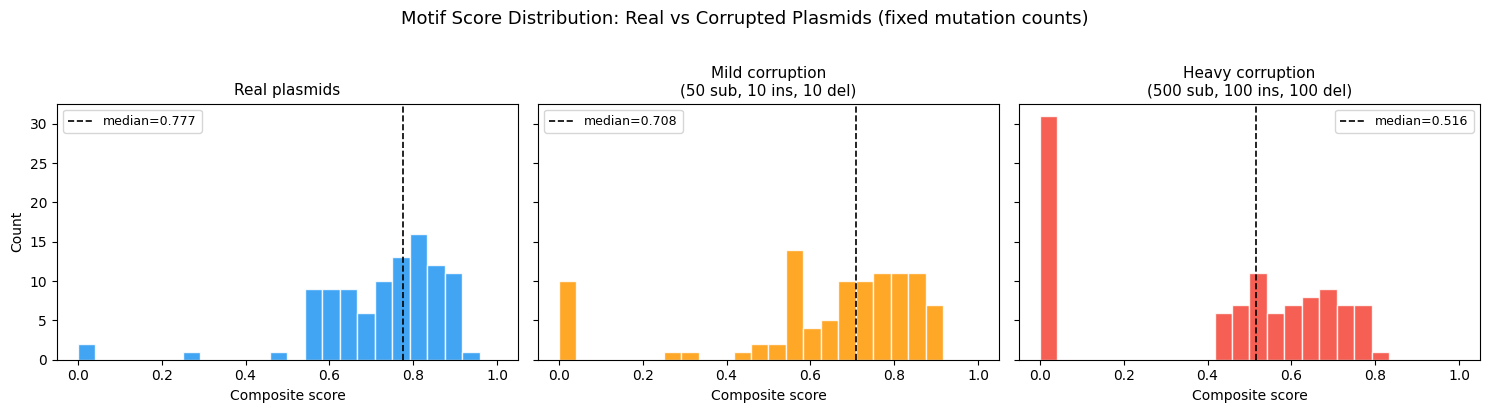

Condition                   Mean  Median    Std    Min    Max
------------------------------------------------------------
Real                       0.728   0.777  0.156  0.000  0.922
Mild corruption            0.637   0.708  0.248  0.000  0.911
Heavy corruption           0.421   0.516  0.297  0.000  0.823


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import random

motif_token_set = set(motifs.token.unique())
sample = prompt_pairs[prompt_pairs.sequence.str.len() > 100].sample(100, random_state=42)

def score_row(row, seq_override=None, corrupt_fn=None):
    """Score a single row against its expected annotation tokens.
    
    Pass seq_override to score a specific sequence, or corrupt_fn
    to apply a transformation to the row's sequence before scoring.
    """
    prompt = row.prompt
    all_tokens = prompt.replace("<BOS>", "").replace("<SEP>", "").replace("><", "> <").split()
    expected_tokens = [t for t in all_tokens if t in motif_token_set]
    if not expected_tokens:
        return None

    if seq_override is not None:
        seq = seq_override
    elif corrupt_fn is not None:
        seq = corrupt_fn(row.sequence)
    else:
        seq = row.sequence

    scorer = MotifScorer(seq)
    result = scorer.score(expected_tokens, motifs, sharpness=2.0)
    return result["composite"]

real_scores = sample.apply(score_row, axis=1).dropna()

mild_scores = sample.apply(
    lambda r: score_row(r, corrupt_fn=lambda s: corrupt_plasmid(s, n_sub=50, n_ins=10, n_del=10, seed=42)),
    axis=1
).dropna()

broken_scores = sample.apply(
    lambda r: score_row(r, corrupt_fn=lambda s: corrupt_plasmid(s, n_sub=500, n_ins=100, n_del=100, seed=42)),
    axis=1
).dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, sharex=True)
bins = np.linspace(0, 1, 25)

for ax, scores, title, color in zip(
    axes,
    [real_scores, mild_scores, broken_scores],
    ["Real plasmids", "Mild corruption\n(50 sub, 10 ins, 10 del)", "Heavy corruption\n(500 sub, 100 ins, 100 del)"],
    ["#2196F3", "#FF9800", "#F44336"],
):
    ax.hist(scores, bins=bins, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(scores.median(), color="black", linestyle="--", linewidth=1.2, label=f"median={scores.median():.3f}")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Composite score")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Count")
fig.suptitle("Motif Score Distribution: Real vs Corrupted Plasmids (fixed mutation counts)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'Condition':<25s} {'Mean':>6s} {'Median':>7s} {'Std':>6s} {'Min':>6s} {'Max':>6s}")
print("-" * 60)
for name, s in [("Real", real_scores), ("Mild corruption", mild_scores), ("Heavy corruption", broken_scores)]:
    print(f"{name:<25s} {s.mean():6.3f} {s.median():7.3f} {s.std():6.3f} {s.min():6.3f} {s.max():6.3f}")

### Proportional Corruption Rates

Fixed mutation counts don't account for plasmid length variation. Re-score with mutation rates proportional to sequence length (5% and 20% substitution rates), then examine the paired score drops.

In [16]:
mild_scores = sample.apply(
    lambda r: score_row(r, corrupt_fn=lambda s: corrupt_plasmid(
        s, 
        n_sub=int(len(s) * 0.05),  # 5% substitution rate
        n_ins=int(len(s) * 0.01), 
        n_del=int(len(s) * 0.01),
    )),
    axis=1
).dropna()

broken_scores = sample.apply(
    lambda r: score_row(r, corrupt_fn=lambda s: corrupt_plasmid(
        s, 
        n_sub=int(len(s) * 0.20),  # 20% substitution rate
        n_ins=int(len(s) * 0.05), 
        n_del=int(len(s) * 0.05),
    )),
    axis=1
).dropna()

Paired score drops: for each plasmid, the delta between its real score and its corrupted score.

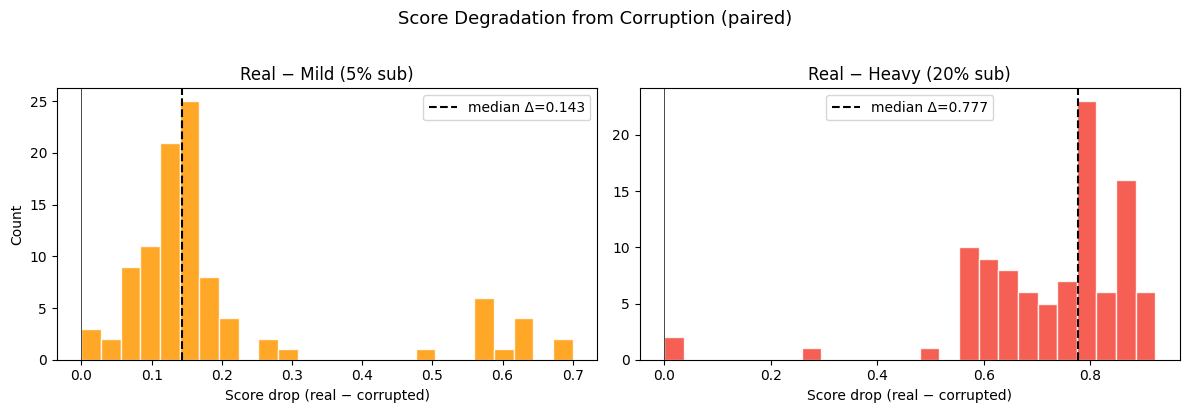

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

delta_mild = real_scores.values - mild_scores.values
delta_broken = real_scores.values - broken_scores.values

for ax, delta, title, color in zip(
    axes,
    [delta_mild, delta_broken],
    ["Real − Mild (5% sub)", "Real − Heavy (20% sub)"],
    ["#FF9800", "#F44336"],
):
    ax.hist(delta, bins=25, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", linestyle="-", linewidth=0.5)
    ax.axvline(np.median(delta), color="black", linestyle="--", 
               label=f"median Δ={np.median(delta):.3f}")
    ax.set_xlabel("Score drop (real − corrupted)")
    ax.set_title(title)
    ax.legend()

axes[0].set_ylabel("Count")
fig.suptitle("Score Degradation from Corruption (paired)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Comparison with Random DNA Baseline

Add a length-matched random DNA baseline to establish a scoring floor. Reuses `real_scores`, `broken_scores`, `sample`, and `score_row` from above.

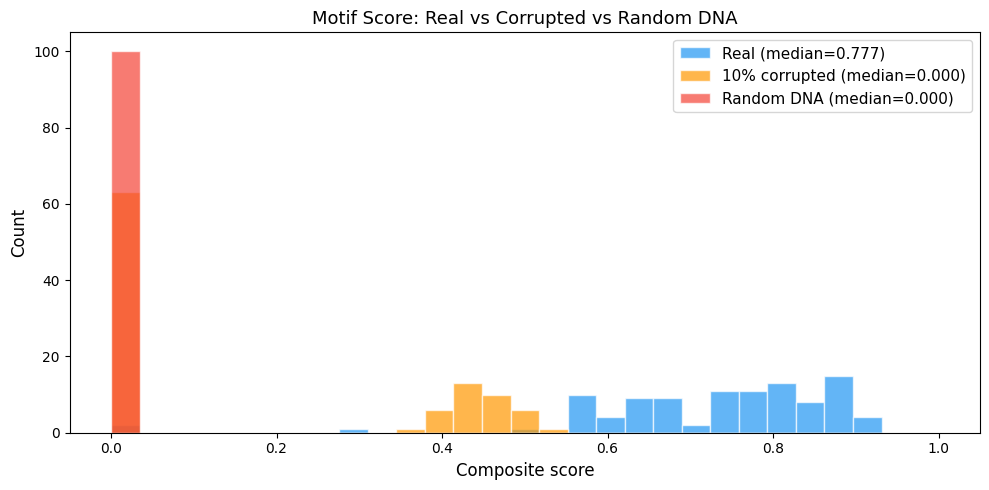


Condition                   Mean  Median    Std    Min    Max
------------------------------------------------------------
Real                       0.728   0.777  0.156  0.000  0.922
20% corrupted              0.165   0.000  0.217  0.000  0.549
Random DNA                 0.000   0.000  0.000  0.000  0.000


In [18]:
heavy_scores = sample.apply(
    lambda r: score_row(r, seq_override=corrupt_plasmid(
        r.sequence,
        n_sub=int(len(r.sequence) * 0.10),
        n_ins=int(len(r.sequence) * 0.05),
        n_del=int(len(r.sequence) * 0.05),
    )),
    axis=1
).dropna()

random_scores = sample.apply(
    lambda r: score_row(r, seq_override=''.join(
        random.choice("ATGC") for _ in range(len(r.sequence))
    )),
    axis=1
).dropna()

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 1, 30)

ax.hist(real_scores, bins=bins, alpha=0.7, color="#2196F3", label=f"Real (median={real_scores.median():.3f})", edgecolor="white")
ax.hist(heavy_scores, bins=bins, alpha=0.7, color="#FF9800", label=f"10% corrupted (median={heavy_scores.median():.3f})", edgecolor="white")
ax.hist(random_scores, bins=bins, alpha=0.7, color="#F44336", label=f"Random DNA (median={random_scores.median():.3f})", edgecolor="white")

ax.set_xlabel("Composite score", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Motif Score: Real vs Corrupted vs Random DNA", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n{'Condition':<25s} {'Mean':>6s} {'Median':>7s} {'Std':>6s} {'Min':>6s} {'Max':>6s}")
print("-" * 60)
for name, s in [("Real", real_scores), ("20% corrupted", heavy_scores), ("Random DNA", random_scores)]:
    print(f"{name:<25s} {s.mean():6.3f} {s.median():7.3f} {s.std():6.3f} {s.min():6.3f} {s.max():6.3f}")

## Known Limitations

- We aren't getting a ton of separation between good plasmids and mildly corrupted plasmids.

- **DB coverage is imperfect.** Not every annotation token has a high-quality reference sequence in the motif database. Tokens without any DB reference get a score of 0 and are excluded from the quality calculation, contributing only through the recall penalty. This means composite scores are partly a function of DB completeness, not just sequence quality.

- **Coverage metric is conservative.** Coverage is defined as `matches / motif_len` — the fraction of the reference motif that aligned identically. For annotations like ColE1 ori, the DB reference (589bp) is longer than the functional region actually present in most plasmids (~370bp), so coverage caps around 63% even for a perfect plasmid. This is a DB curation issue.

- **Semi-global alignment always produces a hit.** `sg_qx` will force-align any motif somewhere in the target, even if there's no real homology. We filter by `min_pct_id` (default 70%) and `min_coverage` (default 50%), but some noise hits survive, particularly for long motifs (~80% identity at ~500bp is parasail's noise floor against random DNA).

- **Cross-token dedup uses IoU, not biological knowledge.** Two different functional elements that genuinely overlap in the genome (e.g. a promoter within an ORF) could be incorrectly deduplicated if their IoU exceeds the threshold (default 0.3). This is rare for typical plasmid annotations but possible.

- **Protein alignments use 6-frame translation.** Protein motifs are scored against all 6 reading frames and the best frame is kept. The protein-to-DNA coordinate mapping assumes standard codon tables and no frameshifts, which is correct for well-formed plasmids but may mislocalize hits in heavily corrupted sequences.

- **Score distribution for real plasmids is broad (0.35–0.95).** This variance is dominated by differences in annotation complexity and DB coverage across plasmids, not by sequence quality. For RL/GRPO, this is acceptable because the reward compares sequences generated for the *same prompt* (same expected tokens), so the DB coverage variance cancels out in within-batch comparisons.

## DNA Repair for DPO Pair Construction

The scorer doubles as a **repair tool** for building DPO (Direct Preference Optimization) training pairs. The idea:

1. **Generate** a plasmid sequence from the model (this is the *rejected* candidate)
2. **Align** expected motifs against it — find regions where the model got the right gene but truncated or garbled it
3. **Splice** in the full reference sequence at each truncated site → this is the *chosen* candidate

The repair targets hits where **identity is high** (the model placed the right gene) but **coverage is low** (it's incomplete). This produces a minimal edit — the repaired sequence stays mostly on-policy, differing only at the truncated motifs.

### Repair criteria

| Parameter | Default | Meaning |
|-----------|---------|---------|
| `min_pct_id` | 90 | Must be the right gene variant (high identity) |
| `min_coverage` | 40 | Enough aligned to trust the location |
| `max_coverage` | 85 | Below this threshold = truncated, worth repairing |

Hits with coverage ≥ `max_coverage` are already good enough and left alone. Protein hits are skipped (repair operates on DNA coordinates only).

In [19]:
corrupted_puc19 = corrupt_plasmid(pUC19, n_sub=30, n_ins=5, n_del=20, seed=7)

scorer = MotifScorer(corrupted_puc19)
result = scorer.repair(
    expected_tokens=['<AMR_AMPICILLIN>', '<ELEM_MCS>', '<ORI_COLE1>', '<PROM_AMPR>', '<PROM_LAC>'],
    motif_db=motifs,
    min_pct_id=90,
    min_coverage=40,
    max_coverage=85,
)

print(f"Original length:  {result['original_len']}")
print(f"Repaired length:  {result['repaired_len']}")
print(f"Repairs applied:  {result['n_repairs']}")
print()
for r in result["repairs"]:
    print(f"  {r['token']:25s}  pct_id={r['pct_id']:.1f}  cov={r['coverage']:.1f}  "
          f"region=[{r['dna_start']}:{r['dna_end']}]  {r['old_len']}bp → {r['new_len']}bp")

Original length:  2716
Repaired length:  2935
Repairs applied:  1

  <ORI_COLE1>                pct_id=98.4  cov=61.8  region=[2346:2715]  370bp → 589bp


In [20]:
expected = ['<AMR_AMPICILLIN>', '<ELEM_MCS>', '<ORI_COLE1>', '<PROM_AMPR>', '<PROM_LAC>']

rejected_scorer = MotifScorer(corrupted_puc19)
rejected_result = rejected_scorer.score(expected, motifs, sharpness=3.0)

chosen_scorer = MotifScorer(result["repaired_seq"])
chosen_result = chosen_scorer.score(expected, motifs, sharpness=3.0)

print(f"{'':30s} {'Rejected':>10s} {'Chosen':>10s}")
print("-" * 55)
print(f"{'Composite':30s} {rejected_result['composite']:10.4f} {chosen_result['composite']:10.4f}")
print(f"{'Quality':30s} {rejected_result['quality']:10.4f} {chosen_result['quality']:10.4f}")
print(f"{'Recall':30s} {rejected_result['recall']:10.4f} {chosen_result['recall']:10.4f}")
print()
for tok in expected:
    rej = rejected_result["token_scores"][tok]
    cho = chosen_result["token_scores"][tok]
    print(f"  {tok:28s}  rej={rej['score']:.3f} (cov={rej['coverage']:5.1f})  "
          f"cho={cho['score']:.3f} (cov={cho['coverage']:5.1f})")

                                 Rejected     Chosen
-------------------------------------------------------
Composite                          0.6750     0.8597
Quality                            0.7500     0.9552
Recall                             0.8000     0.8000

  <AMR_AMPICILLIN>              rej=0.980 (cov= 98.0)  cho=0.980 (cov= 98.0)
  <ELEM_MCS>                    rej=0.000 (cov=  0.0)  cho=0.000 (cov=  0.0)
  <ORI_COLE1>                   rej=0.724 (cov= 61.8)  cho=1.000 (cov=100.0)
  <PROM_AMPR>                   rej=0.960 (cov= 97.1)  cho=0.960 (cov= 97.1)
  <PROM_LAC>                    rej=1.000 (cov=100.0)  cho=1.000 (cov=100.0)


### DPO Integration

In practice, the repair loop runs after generation:

```python
scorer = MotifScorer(generated_sequence)
result = scorer.repair(
    expected_tokens, motifs,
    min_pct_id=90,      # must be the right gene
    min_coverage=40,     # enough to trust location
    max_coverage=85,     # below this = truncated, repair it
)
repaired = result["repaired_seq"]  # use as DPO "chosen"
# generated_sequence is DPO "rejected"
```

The chosen/rejected pair is close in token space (most of the sequence is identical), so the DPO gradient targets exactly the truncation failures rather than learning to rewrite the entire plasmid.

# Part 2: Pretrained Model Generation

Test each model variant by generating plasmid sequences conditioned on annotation prompts, then score them with the motif scorer above.

In [21]:
base_model = "McClain/PlasmidLM"
kmer_model = "McClain/PlasmidLM-kmer6"
moe_kmer_model = "McClain/PlasmidLM-kmer6-MoE"

`base_model` uses single-nucleotide response tokens so we need longer responses. The others are 6-mers with overlap 3. We are aiming for around 8k nt responses.

### Single-Nucleotide Model (PlasmidLM)

In [22]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import transformers

print(f"Transformers version: {transformers.__version__}")

model = AutoModelForCausalLM.from_pretrained("McClain/PlasmidLM", trust_remote_code=True, force_download=True)
tokenizer = AutoTokenizer.from_pretrained("McClain/PlasmidLM", trust_remote_code=True, force_download=True)

# Condition on antibiotic resistance + origin of replication
prompt = "<BOS><AMR_KANAMYCIN><ORI_COLE1><SEP>"
inputs = tokenizer(prompt, return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=4096, temperature=0.8, do_sample=True, top_p=0.95)
print(tokenizer.decode(outputs[0].tolist()))


Transformers version: 5.0.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

configuration_plasmid_lm.py: 0.00B [00:00, ?B/s]

...

tokenization_plasmid_lm.py: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

<BOS><AMR_KANAMYCIN><ORI_COLE1><SEP>AGCGCCCAATACGCAAACCGCCTCTCCCCGCGCGTTGGCCGATTCATTAATGCAGCTGGCACGACAGGTTTCCCGACTGGAAAGCGGGCAGTGAGCGCAACGCAATTAATGTGAGTTAGCTCACTCATTAGGCACCCCAGGCTTTACACTTTATGCTTCCGGCTCGTATGTTGTGTGGAATTGTGAGCGGATAACAATTTCACACAGGAAACAGCTATGACCATGATTACGCCAAGCGCGCAATTAACCCTCACTAAAGGGAACAAAAGCTGGAGCTCCACCGCGGTGGCGGCCGCTCTAGAACTAGTCGATCCGCCGGGCTGCAGGAATTCGATATCAAGGTTATCGATACCGTCCACCTCGAGGGGGGGCCCGGTACCCAATTCGCCCTATAGTGAGTCGTATTACGCGCGCTCACTGGCCGTCGTTTTACAACGTCGTGACTGGGAAAACCCTGGCGTTACCCAACTTAATCGCCTTGCAGCACATCCCCCTTTCGCCAGCTGGCGTAATAGCGAAGAGGCCCGCACCGATCGCCCTTCCCAACAGTTGCGCAGCCTGAATGGCGAATGGACGCGCCCTGTAGCGGCGCATTAAGCGCGGCGGGTGTGGTGGTTACGCGCAGCGTGACCGCTACACTTGCCAGCGCCCTAGCGCCCGCTCCTTTCGCTTTCTTCCCTTCCTTTCTCGCCACGTTCGCCGGCTTTCCCCGTCAAGCTCTAAATCGGGGGCTCCCTTTAGGGTTCCGATTTAGTGCTTTACGGCACCTCGACCCCAAAAAACTTGATTAGGGTGATGGTTCACGTAGTGGGCCATCGCCCTGATAGACGGTTTTTCGCCCTTTGACGTTGGAGTCCACGTTCTTTAATAGTGGACTCTTGTTCCAAACTGGAACAACACTCAACCCTATCTCGGTCTATTCTTTTGATTTATAAGGGATTTTGCCGATTTCGGCCTATTGGTT

### K-mer MoE Model (PlasmidLM-kmer6-MoE)

In [23]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model = AutoModelForCausalLM.from_pretrained("McClain/PlasmidLM-kmer6-MoE", trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("McClain/PlasmidLM-kmer6-MoE", trust_remote_code=True)

# Condition on antibiotic resistance + origin of replication
prompt = "<BOS><AMR_KANAMYCIN><ORI_COLE1><SEP>"
inputs = tokenizer(prompt, return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=512, temperature=0.8, do_sample=True, top_p=0.95)
print(tokenizer.decode(outputs[0].tolist()))


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

<BOS><AMR_KANAMYCIN><ORI_COLE1><SEP>GGACTCACCGAAAACACCGTGATGCCCTATGCATGCACCTGCGTGGCACTTGTAGCAGTTTACCAGATCTACCAGCCCAGTACCCTCAATCTGTGCTGTAGTCTTTATGAAGTCGGTAAGGTTCCTGTAACAAGCTCGCTGGGATTCAATAGAAAATACAAGAGATGAAAAAGAAAGATACATTGATGACCCACAATTATTTAATCATGTTTACCAGTCCAGGCCTGCAGAGGTACCGGGTTCTGCTCATACAACAGATCTGGATTAGAAAGGGCTTGACTAAACCATACTTCCTGTTGAGAGGCCTTTCTCAGTGAGAAATCTAGGAGGAGCAGAAGCTGACAGTGTTCCAGAATGTGGTGTTGAAGCGGAACCGCATGATGATGATGATGTTGTGCATCACCAGGGCCACCTACTGGTCTATCCCAAACTTCCTGACACAGTGGCTCCAACAGAAAATCACAAGCAACAAGCCCTCAAGTATTGACACGCCACTGAAGTATTATGTGAAGAATGAACTGAAGAAAGTCTGCTGGGTAGAATCCTTAATTTAGTTCAAAGTGTAGTTGCTGAGATGTTTCCCAATCAAATTTGTTTGCTCTATTAAGATCAAGTTCTTTAGGCTGAAGGATGAGGTTCGCCAGCATGAGATTCGGAAGCAGAAAGAGTGCTTCATCGAGATCCAGCACTTCTACAGGGTGTGAGTCGTCTAGTACAGAAGTGAACAAAACTGGCCTTCTCCAAATTATTTGTAGAAATAAGAGAATTGCTTGCGGCCGCACTAAAAAGACCTTTTATTTGTGAAAACTACACAGACCTTGGAGAGAGAGAATATGGAGCAGAACCGCATGCGATTGATCCGCTTGAATGCCAAGATCTGTATGAAGTAAGGATTTCAACTTCAAGTCCAGTATTCAGTGGAGACACCTAAAACAACTTGTATCATATATCACCCAGCTTTCTT

### Evaluation Pipeline

Optimized for A100 throughput:
- **Batched generation**: all prompts × `top_n` samples are generated in one (or few) GPU calls instead of one prompt at a time
- **`torch.compile`**: compiles the model for faster forward passes (with `dynamic=True` to handle varying sequence lengths)
- **Threaded scoring**: motif alignment (parasail C library) runs in parallel threads since it releases the GIL
- **Left-padding**: tokenizer is set to `padding_side="left"` so batched generation works correctly

In [24]:
import re
import torch
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
from concurrent.futures import ThreadPoolExecutor
from collections import defaultdict
from tqdm.notebook import tqdm
import time


def load_model(model_name: str, device="cuda", dtype=torch.bfloat16, compile_model=True):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_name, trust_remote_code=True, torch_dtype=dtype
    ).to(device).eval()

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = tokenizer.pad_token_id
    tokenizer.padding_side = "left"

    if compile_model:
        try:
            model = torch.compile(model, dynamic=True)
            print(f"  torch.compile enabled")
        except Exception as e:
            print(f"  torch.compile failed ({e}), using eager mode")

    return model, tokenizer


def batch_generate(
    model, tokenizer, prompt_strs, max_new_tokens,
    temperature=0.8, top_p=0.95, num_samples=3,
    device="cuda", batch_size=0,
):
    """Generate num_samples sequences per prompt in batched GPU calls.
    
    Returns list of (prompt_idx, decoded_text) tuples.
    """
    expanded = []
    prompt_indices = []
    for pi, ps in enumerate(prompt_strs):
        for _ in range(num_samples):
            expanded.append(ps)
            prompt_indices.append(pi)

    if batch_size <= 0:
        batch_size = len(expanded)

    all_generated = []

    for start in tqdm(range(0, len(expanded), batch_size), desc="Generating"):
        batch = expanded[start:start + batch_size]
        batch_idx = prompt_indices[start:start + batch_size]

        inputs = tokenizer(batch, return_tensors="pt", padding=True).to(device)
        input_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=True,
                top_p=top_p,
            )

        generated_ids = outputs[:, input_len:]

        for i in range(len(batch)):
            text = tokenizer.decode(generated_ids[i], skip_special_tokens=True)
            all_generated.append((batch_idx[i], text))

    return all_generated


def score_sequences(generated, prompt_token_lists, motifs_df,
                    sharpness=3.0, n_workers=4, **score_kwargs):
    """Score all generated sequences using parallel threads.
    
    parasail's C alignment code releases the GIL, so threads
    give near-linear speedup for the CPU-bound scoring phase.
    """
    motif_records = motifs_df.to_dict("records")

    def _score_one(args):
        pi, text = args
        dna_seq = re.sub(r'<[^>]+>', '', text)
        scorer = MotifScorer(dna_seq)
        result = scorer.score(
            prompt_token_lists[pi], motif_records,
            sharpness=sharpness, **score_kwargs,
        )
        return {
            "prompt_idx": pi,
            "sequence": scorer.target_dna,
            "length": len(scorer.target_dna),
            "composite": result["composite"],
            "geo_mean": result["geo_mean"],
            "recall": result["recall"],
            "found": result["found"],
            "expected": result["expected"],
            "token_scores": result["token_scores"],
            "hits": result["hits"],
        }

    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        results = list(tqdm(
            pool.map(_score_one, generated),
            total=len(generated), desc="Scoring",
        ))

    return results


def evaluate_prompts(
    model, tokenizer,
    prompts: list[list[str]],
    motifs: pd.DataFrame,
    max_new_tokens: int = 2000,
    temperature: float = 0.8,
    top_n: int = 3,
    sharpness: float = 3.0,
    batch_size: int = 0,
    n_score_workers: int = 4,
    device: str = "cuda",
    **score_kwargs,
) -> pd.DataFrame:
    """Evaluate a model across multiple prompts using batched generation
    and parallel scoring.

    Args:
        prompts: list of prompt token lists
        batch_size: GPU generation batch size (0 = all at once)
        n_score_workers: threads for parallel motif scoring
    """
    prompt_strs = [f"<BOS>{''.join(toks)}<SEP>" for toks in prompts]

    t0 = time.time()
    generated = batch_generate(
        model, tokenizer, prompt_strs, max_new_tokens,
        temperature=temperature, num_samples=top_n,
        device=device, batch_size=batch_size,
    )
    t_gen = time.time() - t0

    t0 = time.time()
    scored = score_sequences(
        generated, prompts, motifs,
        sharpness=sharpness, n_workers=n_score_workers,
        **score_kwargs,
    )
    t_score = time.time() - t0

    print(f"  Generation: {t_gen:.1f}s | Scoring: {t_score:.1f}s "
          f"| {len(generated)} sequences total")

    by_prompt = defaultdict(list)
    for s in scored:
        by_prompt[s["prompt_idx"]].append(s)

    rows = []
    for pi, toks in enumerate(prompts):
        candidates = by_prompt.get(pi, [])
        if not candidates:
            continue
        composites = [c["composite"] for c in candidates]
        best = max(candidates, key=lambda c: c["composite"])
        rows.append({
            "prompt": ''.join(toks),
            "composite": best["composite"],
            "geo_mean": best["geo_mean"],
            "recall": best["recall"],
            "found": best["found"],
            "expected": best["expected"],
            "length": best["length"],
            "best_of": len(candidates),
            "mean_composite": sum(composites) / len(composites),
            "token_scores": best["token_scores"],
        })

    return pd.DataFrame(rows)

In [25]:
print('test')

test


### Head-to-Head Evaluation

Sample 20 random prompts from the training set, generate sequences from each model, score them with the motif scorer, and compare. Models are loaded one at a time to fit in GPU memory.

In [26]:
eval_sample = prompt_pairs[prompt_pairs.sequence.str.len() > 500].sample(20, random_state=99)

eval_prompts = []
for _, row in eval_sample.iterrows():
    raw = row.prompt.replace("<BOS>", "").replace("<SEP>", "").replace("><", "> <").split()
    tokens = [t for t in raw if t.startswith("<") and t.endswith(">") and t in motif_token_set]
    if tokens:
        eval_prompts.append(tokens)

print(f"Sampled {len(eval_prompts)} prompts with scorable tokens")
for i, p in enumerate(eval_prompts[:5]):
    print(f"  {i}: {' '.join(p)}")
print(f"  ... ({len(eval_prompts) - 5} more)")

Sampled 20 prompts with scorable tokens
  0: <AMR_AMPICILLIN> <ORI_COLE1> <ORI_F1> <ORI_SV40> <PROM_AMPR> <PROM_EF1A> <PROM_LAC> <PROM_RSV> <PROM_T3> <PROM_T7> <PROM_U6> <ELEM_CPPT> <ELEM_IRES> <ELEM_LTR_3> <ELEM_LTR_5> <ELEM_POLYA_SV40> <ELEM_PSI> <ELEM_TRACRRNA> <ELEM_WPRE>
  1: <AMR_AMPICILLIN> <ORI_COLE1> <ORI_F1> <PROM_AMPR> <PROM_CAG> <ELEM_AAV_ITR> <ELEM_CMV_ENHANCER> <ELEM_IRES> <ELEM_POLYA_BGH> <ELEM_TRACRRNA> <TAG_NLS>
  2: <ORI_COLE1> <PROM_T7> <ELEM_IRES> <ELEM_TRACRRNA>
  3: <AMR_AMPICILLIN> <ORI_COLE1> <PROM_AMPR> <ELEM_IRES> <ELEM_TRACRRNA> <REPORTER_GFP>
  4: <AMR_AMPICILLIN> <ORI_COLE1> <ORI_F1> <PROM_AMPR> <PROM_LAC> <PROM_SP6> <PROM_T7> <ELEM_IRES> <ELEM_TRACRRNA>
  ... (15 more)


In [27]:
import gc

models_to_eval = {
    "PlasmidLM (1-nt)": {
        "name": base_model,
        "max_new_tokens": 8192,
        "batch_size": 30,   # longer sequences → smaller batches
    },
    "PlasmidLM-kmer6": {
        "name": kmer_model,
        "max_new_tokens": 2700,
        "batch_size": 0,    # 0 = all 60 sequences in one batch
    },
    "PlasmidLM-kmer6-MoE": {
        "name": moe_kmer_model,
        "max_new_tokens": 2700,
        "batch_size": 0,
        "compile": False,  # MoE dispatch has data-dependent shapes → compile causes graph breaks
    },
}

all_results = {}

for label, cfg in models_to_eval.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {label} ({cfg['name']})")
    print(f"{'='*60}")

    model, tokenizer = load_model(cfg["name"], compile_model=cfg.get("compile", True))

    df = evaluate_prompts(
        model, tokenizer, eval_prompts, motifs,
        max_new_tokens=cfg["max_new_tokens"],
        temperature=0.3,
        top_n=3,
        sharpness=3.0,
        batch_size=cfg["batch_size"],
        n_score_workers=4,
    )
    df["model"] = label
    all_results[label] = df

    print(f"  composite: mean={df['composite'].mean():.3f}  median={df['composite'].median():.3f}")
    print(f"  recall:    mean={df['recall'].mean():.3f}")
    print(f"  length:    mean={df['length'].mean():.0f}")

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()

results_df = pd.concat(all_results.values(), ignore_index=True)
print(f"\nDone — {len(results_df)} total evaluations")


Evaluating: PlasmidLM (1-nt) (McClain/PlasmidLM)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/82 [00:00<?, ?it/s]

  torch.compile enabled


Generating:   0%|          | 0/2 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

  torch.compile enabled


Generating:   0%|          | 0/1 [00:00<?, ?it/s]

Scoring:   0%|          | 0/60 [00:00<?, ?it/s]

  Generation: 436.9s | Scoring: 6.8s | 60 sequences total
  composite: mean=0.659  median=0.698
  recall:    mean=0.405
  length:    mean=5839

Done — 60 total evaluations


/tmp/ipykernel_19965/1805906362.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(box_data, labels=model_order, patch_artist=True, widths=0.6)
/tmp/ipykernel_19965/1805906362.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(recall_data, labels=model_order, patch_artist=True, widths=0.6)
/tmp/ipykernel_19965/1805906362.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = axes[2].boxplot(len_data, labels=model_order, patch_artist=True, widths=0.6)


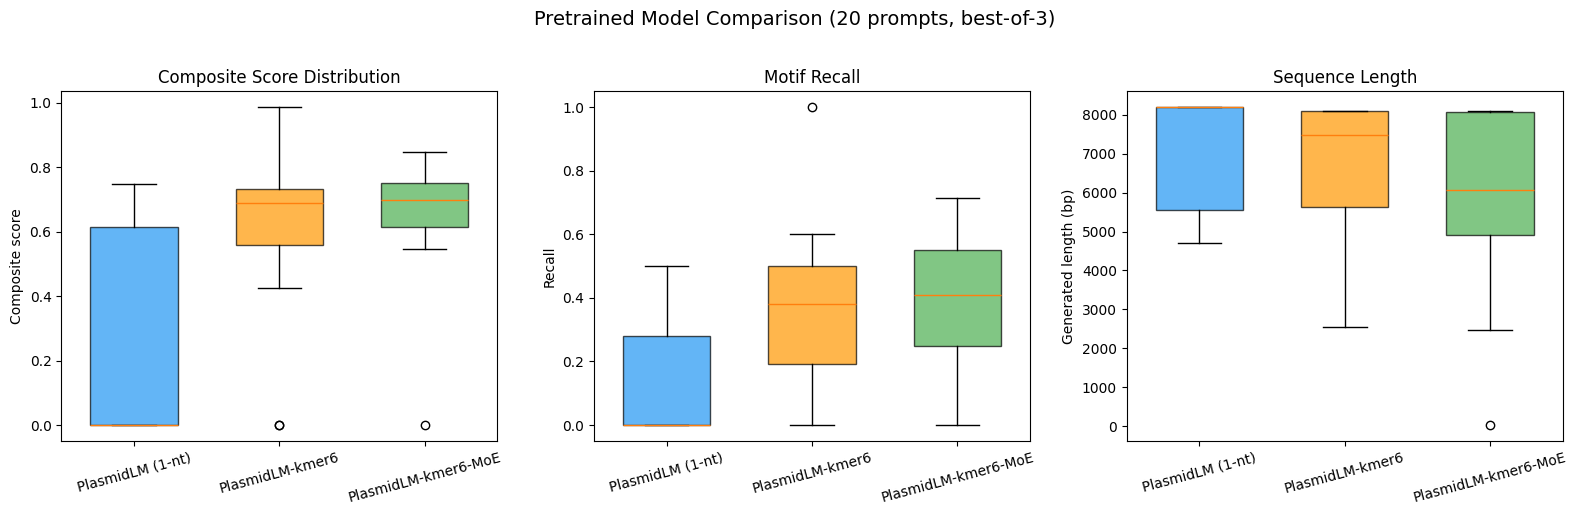

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_order = list(models_to_eval.keys())
colors = ["#2196F3", "#FF9800", "#4CAF50"]

# --- Box plot: composite scores ---
box_data = [all_results[m]["composite"].values for m in model_order]
bp = axes[0].boxplot(box_data, labels=model_order, patch_artist=True, widths=0.6)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel("Composite score")
axes[0].set_title("Composite Score Distribution")
axes[0].tick_params(axis="x", rotation=15)

# --- Box plot: recall ---
recall_data = [all_results[m]["recall"].values for m in model_order]
bp2 = axes[1].boxplot(recall_data, labels=model_order, patch_artist=True, widths=0.6)
for patch, color in zip(bp2["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel("Recall")
axes[1].set_title("Motif Recall")
axes[1].tick_params(axis="x", rotation=15)

# --- Box plot: sequence length ---
len_data = [all_results[m]["length"].values for m in model_order]
bp3 = axes[2].boxplot(len_data, labels=model_order, patch_artist=True, widths=0.6)
for patch, color in zip(bp3["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_ylabel("Generated length (bp)")
axes[2].set_title("Sequence Length")
axes[2].tick_params(axis="x", rotation=15)

fig.suptitle("Pretrained Model Comparison (20 prompts, best-of-3)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

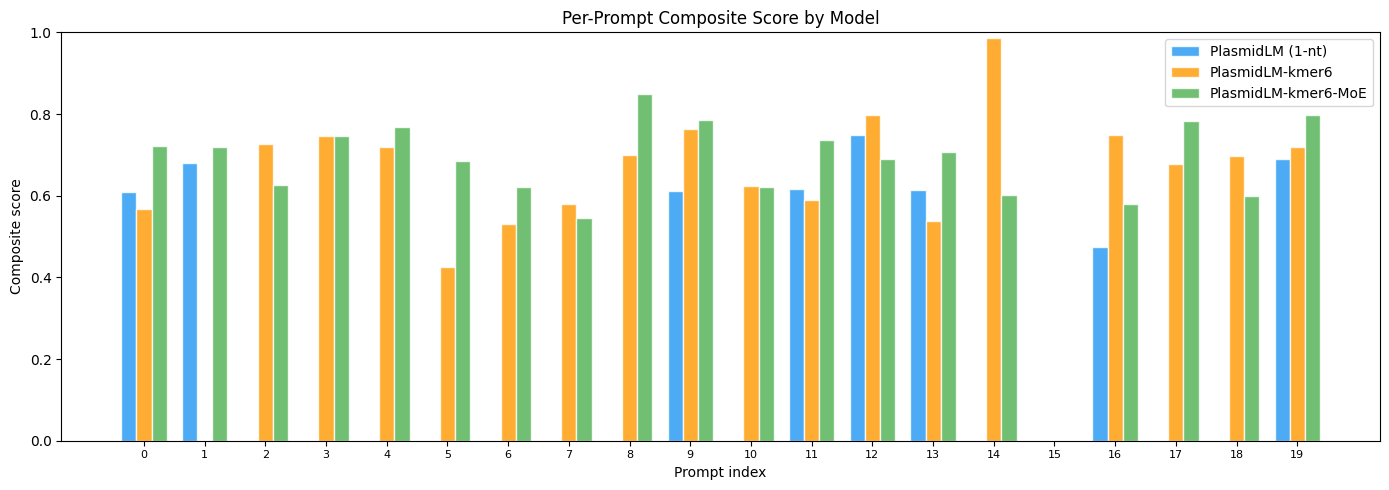

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(eval_prompts))
width = 0.25

for i, (label, color) in enumerate(zip(model_order, colors)):
    scores = all_results[label]["composite"].values
    ax.bar(x + i * width, scores, width, label=label, color=color, alpha=0.8, edgecolor="white")

ax.set_xlabel("Prompt index")
ax.set_ylabel("Composite score")
ax.set_title("Per-Prompt Composite Score by Model")
ax.set_xticks(x + width)
ax.set_xticklabels([str(i) for i in range(len(eval_prompts))], fontsize=8)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [30]:
summary = results_df.groupby("model").agg(
    composite_mean=("composite", "mean"),
    composite_median=("composite", "median"),
    composite_std=("composite", "std"),
    recall_mean=("recall", "mean"),
    geo_mean_mean=("geo_mean", "mean"),
    length_mean=("length", "mean"),
    mean_composite_mean=("mean_composite", "mean"),
).reindex(model_order)

print(summary.to_string(float_format="{:.3f}".format))
print()
print("mean_composite = average across all 3 candidates (not just the best)")
print("composite      = best-of-3 composite score")

                     composite_mean  composite_median  composite_std  recall_mean  geo_mean_mean  length_mean  mean_composite_mean
model                                                                                                                             
PlasmidLM (1-nt)              0.252             0.000          0.321        0.133          0.392     7053.200                0.201
PlasmidLM-kmer6               0.607             0.688          0.239        0.357          0.888     6623.400                0.382
PlasmidLM-kmer6-MoE           0.659             0.698          0.176        0.405          0.941     5838.900                0.445

mean_composite = average across all 3 candidates (not just the best)
composite      = best-of-3 composite score


# Part 3: MoE Expert Analysis

The kmer6-MoE model uses 6 experts with top-2 routing across all 10 decoder layers. Two questions:
1. **Are all experts actually used?** Or do some experts get starved?
2. **Do experts specialize by token type?** Do annotation tokens (e.g. `<AMR_AMPICILLIN>`) route differently than DNA k-mer tokens?

We hook the router linear layers during inference to capture per-token routing decisions without modifying the model code.

In [32]:
moe_model, moe_tokenizer = load_model(moe_kmer_model, compile_model=False)

num_layers = moe_model.config.num_hidden_layers
num_experts = moe_model.config.num_experts
top_k = moe_model.config.num_experts_per_tok
print(f"Layers: {num_layers}, Experts: {num_experts}, Top-k: {top_k}")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

Layers: 10, Experts: 6, Top-k: 2


In [33]:
routing_log = []

def _make_router_hook(layer_idx, top_k):
    """Hook on the router Linear to capture routing decisions."""
    def hook(module, input, output):
        # output = router_logits (B*S, num_experts)
        probs = torch.softmax(output.detach(), dim=-1)
        _, top_idx = torch.topk(probs, top_k, dim=-1)
        routing_log.append({
            "layer": layer_idx,
            "probs": probs.cpu(),
            "top_indices": top_idx.cpu(),
        })
    return hook

hooks = []
for i, layer in enumerate(moe_model.model.layers):
    if hasattr(layer, "moe"):
        h = layer.moe.router.register_forward_hook(_make_router_hook(i, top_k))
        hooks.append(h)

print(f"Registered {len(hooks)} router hooks")

Registered 10 router hooks


In [34]:
routing_log.clear()

moe_prompts = [
    "<BOS><AMR_KANAMYCIN><ORI_COLE1><SEP>",
    "<BOS><AMR_AMPICILLIN><PROM_LAC><ORI_COLE1><ELEM_MCS><SEP>",
    "<BOS><AMR_CHLORAMPHENICOL><ORI_P15A><SEP>",
    "<BOS><AMR_SPECTINOMYCIN><ORI_COLE1><PROM_T7><SEP>",
    "<BOS><AMR_AMPICILLIN><ORI_COLE1><SEP>",
]

all_token_ids = []
all_token_strs = []

for prompt in moe_prompts:
    inputs = moe_tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = moe_model.generate(
            **inputs,
            max_new_tokens=2700,
            temperature=0.3,
            do_sample=True,
            top_p=0.95,
        )
    token_ids = outputs[0].cpu().tolist()
    token_strs = [moe_tokenizer.decode([tid]) for tid in token_ids]
    all_token_ids.append(token_ids)
    all_token_strs.append(token_strs)

print(f"Generated {len(moe_prompts)} sequences")
print(f"Routing entries collected: {len(routing_log)} (expect {len(moe_prompts)} × steps × {num_layers} layers)")
print(f"Sequence lengths: {[len(t) for t in all_token_ids]}")

Generated 5 sequences
Routing entries collected: 111480 (expect 5 × steps × 10 layers)
Sequence lengths: [1131, 2706, 2704, 1926, 2704]


### Expert Utilization

Aggregate all routing decisions across all layers and tokens. If the load balancing loss worked, we expect a roughly uniform distribution across all 6 experts.

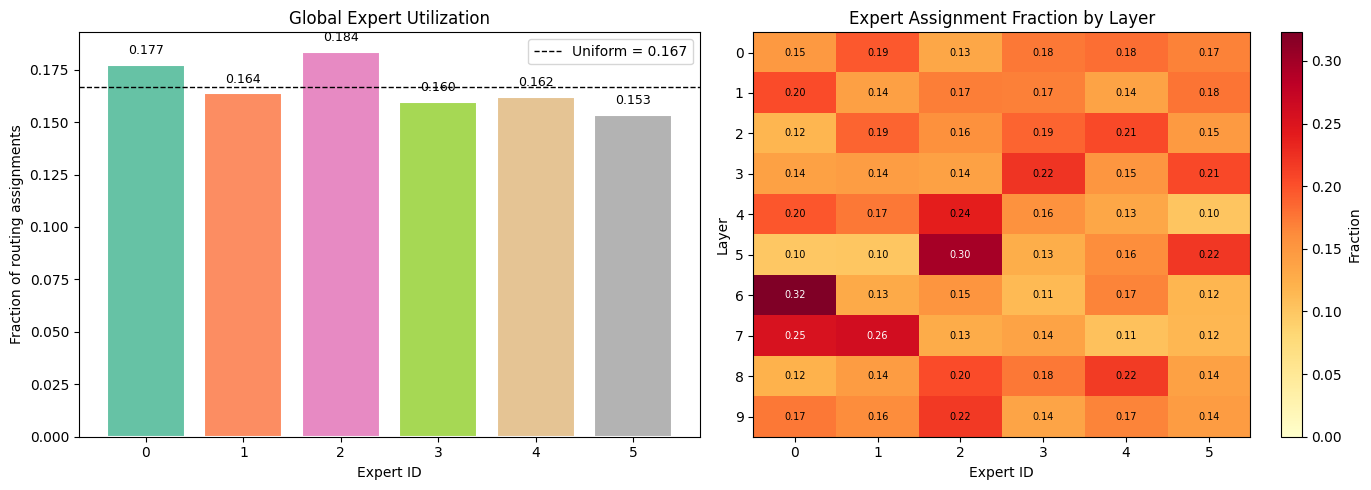


Total routing assignments: 223,320
Expert usage range: 0.1535 – 0.1836
Std across experts: 0.0104 (lower = more balanced)


In [35]:
expert_counts_per_layer = np.zeros((num_layers, num_experts))
total_tokens_per_layer = np.zeros(num_layers)

for entry in routing_log:
    layer = entry["layer"]
    top_idx = entry["top_indices"]  # (num_tokens, top_k)
    for k in range(top_k):
        for expert_id in top_idx[:, k].tolist():
            expert_counts_per_layer[layer, expert_id] += 1
    total_tokens_per_layer[layer] += top_idx.shape[0]

expert_frac_per_layer = expert_counts_per_layer / (total_tokens_per_layer[:, None] * top_k + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Global expert usage ---
global_counts = expert_counts_per_layer.sum(axis=0)
global_frac = global_counts / global_counts.sum()
bars = axes[0].bar(range(num_experts), global_frac, color=plt.cm.Set2(np.linspace(0, 1, num_experts)),
                   edgecolor="white", linewidth=1.5)
axes[0].axhline(1.0 / num_experts, color="black", linestyle="--", linewidth=1,
                label=f"Uniform = {1/num_experts:.3f}")
axes[0].set_xlabel("Expert ID")
axes[0].set_ylabel("Fraction of routing assignments")
axes[0].set_title("Global Expert Utilization")
axes[0].set_xticks(range(num_experts))
axes[0].legend()

for bar, frac in zip(bars, global_frac):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{frac:.3f}", ha="center", fontsize=9)

# --- Per-layer heatmap ---
im = axes[1].imshow(expert_frac_per_layer, aspect="auto", cmap="YlOrRd",
                    vmin=0, vmax=expert_frac_per_layer.max())
axes[1].set_xlabel("Expert ID")
axes[1].set_ylabel("Layer")
axes[1].set_title("Expert Assignment Fraction by Layer")
axes[1].set_xticks(range(num_experts))
axes[1].set_yticks(range(num_layers))
plt.colorbar(im, ax=axes[1], label="Fraction")

for i in range(num_layers):
    for j in range(num_experts):
        axes[1].text(j, i, f"{expert_frac_per_layer[i, j]:.2f}",
                     ha="center", va="center", fontsize=7,
                     color="white" if expert_frac_per_layer[i, j] > 0.25 else "black")

plt.tight_layout()
plt.show()

print(f"\nTotal routing assignments: {int(global_counts.sum()):,}")
print(f"Expert usage range: {global_frac.min():.4f} – {global_frac.max():.4f}")
print(f"Std across experts: {global_frac.std():.4f} (lower = more balanced)")

### Expert Routing by Token Type

Classify each token as one of: **annotation** (e.g. `<AMR_KANAMYCIN>`), **structural** (`<BOS>`, `<SEP>`, `<EOS>`), or **DNA** (k-mer tokens). Then check whether different token types route to different experts.

Since generation is autoregressive, each step processes one new token through all layers. We align the routing log entries with the generated token sequence to recover which expert handled which token.

In [36]:
special_tokens = {"<BOS>", "<SEP>", "<EOS>", "<PAD>", "<UNK>"}

def classify_token(tok_str):
    tok_str = tok_str.strip()
    if tok_str in special_tokens:
        return "structural"
    if tok_str.startswith("<") and tok_str.endswith(">"):
        return "annotation"
    return "dna"

# Reconstruct per-token routing from the log.
# During autoregressive generation, each step fires num_layers hooks
# for a single new token (KV cache means only the last token goes through).
# The prefill step processes all prompt tokens at once.

per_token_routing = []  # list of dicts: token_str, token_type, layer, expert_0, expert_1

log_idx = 0
for seq_i, token_strs in enumerate(all_token_strs):
    prompt_len = len(moe_tokenizer(moe_prompts[seq_i])["input_ids"])

    # Prefill: processes all prompt_len tokens through num_layers layers
    for layer_i in range(num_layers):
        if log_idx >= len(routing_log):
            break
        entry = routing_log[log_idx]
        top_idx = entry["top_indices"]  # (prompt_len, top_k)
        for t in range(min(top_idx.shape[0], prompt_len)):
            tok_str = token_strs[t] if t < len(token_strs) else "?"
            per_token_routing.append({
                "seq": seq_i,
                "pos": t,
                "token": tok_str,
                "type": classify_token(tok_str),
                "layer": entry["layer"],
                "expert_0": top_idx[t, 0].item(),
                "expert_1": top_idx[t, 1].item() if top_k > 1 else -1,
            })
        log_idx += 1

    # Decode steps: one token at a time through num_layers
    for t_pos in range(prompt_len, len(token_strs)):
        for layer_i in range(num_layers):
            if log_idx >= len(routing_log):
                break
            entry = routing_log[log_idx]
            top_idx = entry["top_indices"]  # (1, top_k)
            tok_str = token_strs[t_pos]
            per_token_routing.append({
                "seq": seq_i,
                "pos": t_pos,
                "token": tok_str,
                "type": classify_token(tok_str),
                "layer": entry["layer"],
                "expert_0": top_idx[0, 0].item(),
                "expert_1": top_idx[0, 1].item() if top_k > 1 else -1,
            })
            log_idx += 1

routing_df = pd.DataFrame(per_token_routing)
print(f"Routing entries: {len(routing_df):,}")
print(f"\nToken type distribution:")
print(routing_df.groupby("type").size())

Routing entries: 111,510

Token type distribution:
type
annotation        20
dna           111390
structural       100
dtype: int64


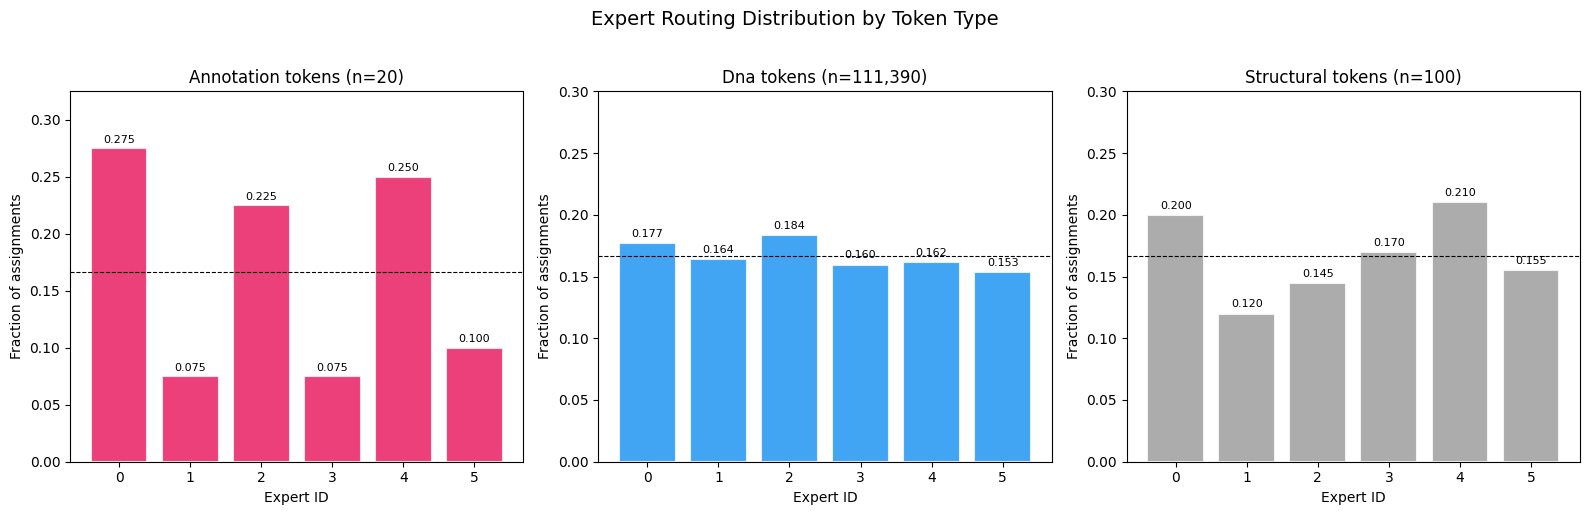

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

token_types = ["annotation", "dna", "structural"]
type_colors = {"annotation": "#E91E63", "dna": "#2196F3", "structural": "#9E9E9E"}

for ax, ttype in zip(axes, token_types):
    subset = routing_df[routing_df["type"] == ttype]
    if subset.empty:
        ax.set_title(f"{ttype} (no tokens)")
        continue

    # Count expert assignments (both top-1 and top-2)
    counts = np.zeros(num_experts)
    for col in ["expert_0", "expert_1"]:
        for eid in subset[col]:
            if 0 <= eid < num_experts:
                counts[eid] += 1
    frac = counts / counts.sum()

    bars = ax.bar(range(num_experts), frac, color=type_colors[ttype],
                  edgecolor="white", alpha=0.85, linewidth=1.5)
    ax.axhline(1/num_experts, color="black", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Expert ID")
    ax.set_ylabel("Fraction of assignments")
    ax.set_title(f"{ttype.capitalize()} tokens (n={len(subset):,})")
    ax.set_xticks(range(num_experts))
    ax.set_ylim(0, max(frac.max() + 0.05, 0.3))

    for bar, f in zip(bars, frac):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{f:.3f}", ha="center", fontsize=8)

fig.suptitle("Expert Routing Distribution by Token Type", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

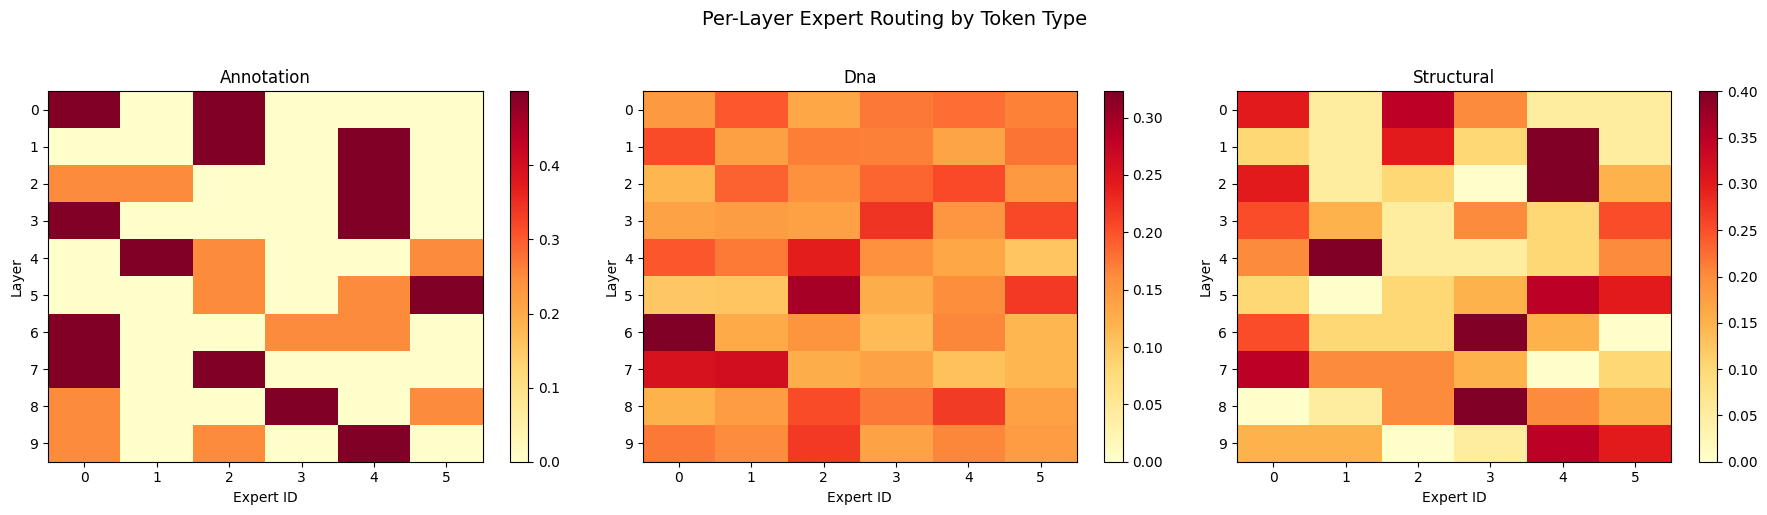

In [38]:
# Per-layer routing heatmap for each token type
fig, axes = plt.subplots(1, len(token_types), figsize=(6 * len(token_types), 5))

for ax, ttype in zip(axes, token_types):
    subset = routing_df[routing_df["type"] == ttype]
    if subset.empty:
        continue

    mat = np.zeros((num_layers, num_experts))
    layer_totals = np.zeros(num_layers)

    for _, row in subset.iterrows():
        layer = row["layer"]
        for col in ["expert_0", "expert_1"]:
            eid = row[col]
            if 0 <= eid < num_experts:
                mat[layer, eid] += 1
        layer_totals[layer] += 1

    # Normalize per layer
    mat = mat / (layer_totals[:, None] * top_k + 1e-9)

    im = ax.imshow(mat, aspect="auto", cmap="YlOrRd", vmin=0, vmax=mat.max())
    ax.set_xlabel("Expert ID")
    ax.set_ylabel("Layer")
    ax.set_title(f"{ttype.capitalize()}")
    ax.set_xticks(range(num_experts))
    ax.set_yticks(range(num_layers))
    plt.colorbar(im, ax=ax)

fig.suptitle("Per-Layer Expert Routing by Token Type", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Per-Annotation Expert Preferences

For each unique annotation token, show which experts it preferentially routes to across all layers. If experts have learned component-level specialization, we'd expect distinct routing signatures per annotation.

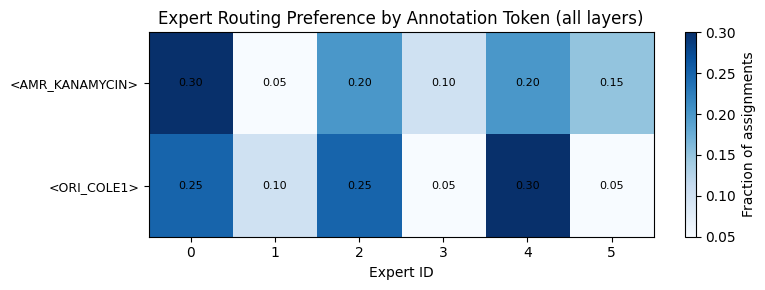

In [39]:
annot_df = routing_df[routing_df["type"] == "annotation"]
unique_annots = sorted(annot_df["token"].unique())

if len(unique_annots) > 0:
    annot_expert_mat = np.zeros((len(unique_annots), num_experts))

    for ai, annot in enumerate(unique_annots):
        subset = annot_df[annot_df["token"] == annot]
        for col in ["expert_0", "expert_1"]:
            for eid in subset[col]:
                if 0 <= eid < num_experts:
                    annot_expert_mat[ai, eid] += 1
        row_sum = annot_expert_mat[ai].sum()
        if row_sum > 0:
            annot_expert_mat[ai] /= row_sum

    fig, ax = plt.subplots(figsize=(8, max(3, len(unique_annots) * 0.5)))
    im = ax.imshow(annot_expert_mat, aspect="auto", cmap="Blues")
    ax.set_yticks(range(len(unique_annots)))
    ax.set_yticklabels(unique_annots, fontsize=9)
    ax.set_xticks(range(num_experts))
    ax.set_xlabel("Expert ID")
    ax.set_title("Expert Routing Preference by Annotation Token (all layers)")
    plt.colorbar(im, ax=ax, label="Fraction of assignments")

    for i in range(len(unique_annots)):
        for j in range(num_experts):
            ax.text(j, i, f"{annot_expert_mat[i, j]:.2f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if annot_expert_mat[i, j] > 0.3 else "black")

    plt.tight_layout()
    plt.show()
else:
    print("No annotation tokens found in routing log")

In [ ]:
for h in hooks:
    h.remove()
hooks.clear()

del moe_model, moe_tokenizer
gc.collect()
torch.cuda.empty_cache()
print("Hooks removed, model freed")

## MoE Inference Optimization

The MoE model was **~7x slower** than the dense kmer model despite having roughly equal active parameters (top-2 of 6 experts ≈ 1/3 of expert params active per token). The bottleneck isn't compute — it's the **sparse dispatch loop**: a Python for-loop over 6 experts with dynamic boolean indexing that `torch.compile` can't trace.

**Strategy: dense batched matmul + mask after.**
1. Pre-stack all 6 expert weight matrices into batched tensors `(E, H, I)` and `(E, I, H)`
2. Run ALL experts on ALL tokens via a single `torch.bmm` (one kernel launch instead of 6)
3. Apply the top-k routing weights as a post-hoc mask
4. This trades ~3x more FLOPs (6 experts, only top-2 selected) for fully static shapes

Each expert MLP is tiny (384 → 1536 → 384, ~1.2M params). On an A100 the extra compute is negligible compared to eliminating the Python dispatch overhead and enabling `torch.compile`.

In [43]:
import importlib, time, gc
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

moe_model_name = "McClain/PlasmidLM-kmer6-MoE"

tokenizer = AutoTokenizer.from_pretrained(moe_model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    moe_model_name, trust_remote_code=True, torch_dtype=torch.bfloat16
).to("cuda").eval()

print(f"Loaded {moe_model_name}")
print(f"  {model.config.num_experts} experts, top-{model.config.num_experts_per_tok}")
print(f"  hidden={model.config.hidden_size}, moe_intermediate={model.config.moe_intermediate_size}")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

Loaded McClain/PlasmidLM-kmer6-MoE
  6 experts, top-2
  hidden=384, moe_intermediate=1536


In [44]:
bench_prompts = [
    "<BOS><AMR_KANAMYCIN><ORI_COLE1><SEP>",
    "<BOS><AMR_AMPICILLIN><PROM_LAC><ORI_COLE1><ELEM_MCS><SEP>",
    "<BOS><AMR_CHLORAMPHENICOL><ORI_P15A><SEP>",
]
bench_inputs = tokenizer(bench_prompts, return_tensors="pt", padding=True).to("cuda")

MAX_NEW_TOKENS = 500
GEN_KWARGS = dict(max_new_tokens=MAX_NEW_TOKENS, temperature=0.8, do_sample=True, top_p=0.95)

def benchmark_generate(model, tag, n_warmup=1, n_runs=3):
    """Time generation across multiple runs, return median tok/s."""
    for _ in range(n_warmup):
        with torch.no_grad():
            model.generate(**bench_inputs, **GEN_KWARGS)
        torch.cuda.synchronize()

    times = []
    total_tokens = 0
    for _ in range(n_runs):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            out = model.generate(**bench_inputs, **GEN_KWARGS)
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0
        times.append(elapsed)
        total_tokens = (out.shape[0] * out.shape[1]) - bench_inputs["input_ids"].numel()

    median = sorted(times)[len(times) // 2]
    tok_per_sec = total_tokens / median
    print(f"  [{tag}] median={median:.2f}s  {tok_per_sec:.0f} tok/s  "
          f"({total_tokens} tokens, {n_runs} runs)")
    return median, tok_per_sec

In [48]:
def patch_moe_dense(model):
    """Monkey-patch all MoE layers in the model for dense batched-matmul inference.
    
    Works on hub-loaded models regardless of whether the local moe.py has
    prepare_dense(). Replaces the forward method on each PlasmidLMSparseMoE
    with a vectorized version that runs all experts on all tokens via bmm.
    """
    patched = 0
    for layer in model.model.layers:
        if not hasattr(layer, "moe"):
            continue
        moe = layer.moe

        # Stack and pre-transpose expert weights once
        up_w = torch.stack([e.up_proj.weight.T for e in moe.experts]).contiguous()
        down_w = torch.stack([e.down_proj.weight.T for e in moe.experts]).contiguous()
        moe.register_buffer("_up_w", up_w, persistent=False)
        moe.register_buffer("_down_w", down_w, persistent=False)

        num_experts = moe.num_experts
        top_k = moe.top_k

        # Capture references for the closure
        _router = moe.router
        _num_experts = num_experts
        _top_k = top_k

        def _make_dense_forward(_moe):
            def forward_dense(hidden_states):
                batch, seq_len, hidden = hidden_states.shape
                flat = hidden_states.view(-1, hidden)
                num_tokens = flat.shape[0]

                router_logits = _moe.router(flat)
                router_probs = F.softmax(router_logits, dim=-1)
                top_weights, top_indices = torch.topk(router_probs, _moe.top_k, dim=-1)
                top_weights = top_weights / top_weights.sum(dim=-1, keepdim=True)

                expert_mask = torch.zeros(
                    num_tokens, _moe.num_experts,
                    device=flat.device, dtype=flat.dtype,
                )
                expert_mask.scatter_(1, top_indices, top_weights)

                x = flat.unsqueeze(0).expand(_moe.num_experts, -1, -1)
                h = torch.bmm(x, _moe._up_w)
                h = F.gelu(h)
                expert_out = torch.bmm(h, _moe._down_w)

                output = torch.einsum("enh,ne->nh", expert_out, expert_mask)
                output = output.view(batch, seq_len, hidden)

                with torch.no_grad():
                    one_hot = torch.zeros(num_tokens, _moe.num_experts, device=flat.device)
                    one_hot.scatter_(1, top_indices, 1.0)
                    f = one_hot.sum(dim=0) / (num_tokens * _moe.top_k)
                P = router_probs.mean(dim=0)
                aux_loss = _moe.num_experts * (f * P).sum()

                return output, aux_loss
            return forward_dense

        moe._original_forward = moe.forward
        moe.forward = _make_dense_forward(moe)
        patched += 1

    print(f"Patched {patched} MoE layers for dense dispatch")
    return model


def unpatch_moe_dense(model):
    """Restore original sparse forward on all MoE layers."""
    for layer in model.model.layers:
        if hasattr(layer, "moe") and hasattr(layer.moe, "_original_forward"):
            layer.moe.forward = layer.moe._original_forward
            del layer.moe._original_forward
            if hasattr(layer.moe, "_up_w"):
                del layer.moe._up_w
                del layer.moe._down_w
    return model

### Baseline: Sparse Dispatch (eager)

In [45]:
sparse_time, sparse_tps = benchmark_generate(model, "sparse (eager)")

  [sparse (eager)] median=53.43s  28 tok/s  (1500 tokens, 3 runs)


### Dense Dispatch (eager)

Monkey-patch each MoE layer to replace the sparse expert loop with a single batched matmul over all experts.

In [49]:
patch_moe_dense(model)
dense_time, dense_tps = benchmark_generate(model, "dense (eager)")

Patched 10 MoE layers for dense dispatch
  [dense (eager)] median=8.10s  185 tok/s  (1500 tokens, 3 runs)


### Dense Dispatch + torch.compile

With static shapes in the MoE forward, `torch.compile` should now be able to fuse operations across the whole model.

In [50]:
compiled_model = torch.compile(model, dynamic=True)
print("torch.compile enabled (dynamic=True)")
compiled_time, compiled_tps = benchmark_generate(compiled_model, "dense + compile")

torch.compile enabled (dynamic=True)
  [dense + compile] median=8.01s  187 tok/s  (1500 tokens, 3 runs)


### Correctness Check

Verify that the dense dispatch produces the same logits as sparse (within bf16 tolerance) on a short forward pass.

In [55]:
check_model = AutoModelForCausalLM.from_pretrained(
    moe_model_name, trust_remote_code=True, torch_dtype=torch.bfloat16
).to("cuda").eval()

test_input = tokenizer("<BOS><AMR_KANAMYCIN><ORI_COLE1><SEP>ATGC", return_tensors="pt").to("cuda")

# --- Per-layer MoE check (isolates the dense forward from propagation) ---
print("Per-layer MoE equivalence:")
with torch.no_grad():
    # Get hidden states at each MoE layer input by running through the model
    hidden = check_model.model.embed_tokens(test_input["input_ids"])
    if check_model.model.rope_cos is None:
        check_model.model._init_rope(hidden.device)
    cos, sin = check_model.model.rope_cos, check_model.model.rope_sin

    layer_max_diffs = []
    for i, layer in enumerate(check_model.model.layers):
        if not hasattr(layer, "moe"):
            continue
        normed = layer.post_attention_layernorm(hidden)
        sparse_out, _ = layer.moe(normed)

        # Temporarily patch this one layer
        patch_moe_dense(check_model)
        dense_out, _ = layer.moe(normed)
        unpatch_moe_dense(check_model)

        diff = (sparse_out.float() - dense_out.float()).abs()
        layer_max_diffs.append(diff.max().item())
        print(f"  Layer {i:2d}: max={diff.max().item():.6f}  mean={diff.mean().item():.8f}")

        # Advance hidden states through this layer for next iteration
        h = layer.input_layernorm(hidden)
        attn_out, new_kv = layer.self_attn(h, cos, sin)
        hidden = hidden + attn_out
        moe_out, _ = layer.moe(layer.post_attention_layernorm(hidden))
        hidden = hidden + moe_out

worst_layer = max(layer_max_diffs)
print(f"\nWorst single-layer max diff: {worst_layer:.6f}")
assert worst_layer < 0.05, f"Single-layer outputs diverged! max={worst_layer}"
print("PASS: individual MoE layers match within bf16 tolerance (0.03125 = 2⁻⁵ rounding quantum)")

# --- Full model logit check ---
with torch.no_grad():
    unpatch_moe_dense(check_model)
    sparse_logits = check_model(**test_input).logits
    patch_moe_dense(check_model)
    dense_logits = check_model(**test_input).logits

max_diff = (sparse_logits.float() - dense_logits.float()).abs().max().item()
mean_diff = (sparse_logits.float() - dense_logits.float()).abs().mean().item()
print(f"\nFull-model logit diff — max: {max_diff:.4f}, mean: {mean_diff:.6f}")
print(f"(expected: small per-layer bf16 diffs amplified through {len(check_model.model.layers)} layers)")

# Verify top-1 predictions mostly agree
sparse_top = sparse_logits.argmax(dim=-1)
dense_top = dense_logits.argmax(dim=-1)
agree_pct = (sparse_top == dense_top).float().mean().item() * 100
print(f"Top-1 prediction agreement: {agree_pct:.1f}%")

del check_model
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

Per-layer MoE equivalence:
Patched 10 MoE layers for dense dispatch
  Layer  0: max=0.007812  mean=0.00023925
Patched 10 MoE layers for dense dispatch
  Layer  1: max=0.015625  mean=0.00013429
Patched 10 MoE layers for dense dispatch
  Layer  2: max=0.015625  mean=0.00018325
Patched 10 MoE layers for dense dispatch
  Layer  3: max=0.031250  mean=0.00095078
Patched 10 MoE layers for dense dispatch
  Layer  4: max=0.015625  mean=0.00065421
Patched 10 MoE layers for dense dispatch
  Layer  5: max=0.007812  mean=0.00036947
Patched 10 MoE layers for dense dispatch
  Layer  6: max=0.015625  mean=0.00036309
Patched 10 MoE layers for dense dispatch
  Layer  7: max=0.015625  mean=0.00070065
Patched 10 MoE layers for dense dispatch
  Layer  8: max=0.015625  mean=0.00018294
Patched 10 MoE layers for dense dispatch
  Layer  9: max=0.015625  mean=0.00066780

Worst single-layer max diff: 0.031250
PASS: individual MoE layers match within bf16 tolerance (0.03125 = 2⁻⁵ rounding quantum)
Patched 10 MoE 

### Summary

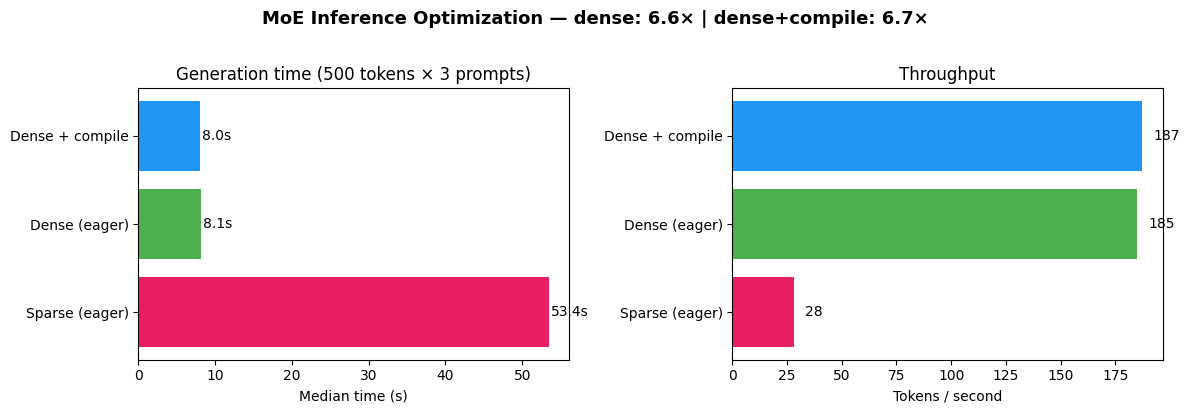


Speedup over sparse baseline:
  Dense (eager):    6.59×
  Dense + compile:  6.67×


In [ ]:
import matplotlib.pyplot as plt

results = {
    "Sparse (eager)": {"time": sparse_time, "tok_s": sparse_tps},
    "Dense (eager)": {"time": dense_time, "tok_s": dense_tps},
    "Dense + compile": {"time": compiled_time, "tok_s": compiled_tps},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

labels = list(results.keys())
times = [results[l]["time"] for l in labels]
tok_s = [results[l]["tok_s"] for l in labels]
colors = ["#E91E63", "#4CAF50", "#2196F3"]

ax1.barh(labels, times, color=colors)
ax1.set_xlabel("Median time (s)")
ax1.set_title(f"Generation time ({MAX_NEW_TOKENS} tokens × {len(bench_prompts)} prompts)")
for i, (t, l) in enumerate(zip(times, labels)):
    ax1.text(t + 0.3, i, f"{t:.1f}s", va="center", fontsize=10)

ax2.barh(labels, tok_s, color=colors)
ax2.set_xlabel("Tokens / second")
ax2.set_title("Throughput")
for i, (t, l) in enumerate(zip(tok_s, labels)):
    ax2.text(t + 5, i, f"{t:.0f}", va="center", fontsize=10)

speedup_dense = sparse_time / dense_time
speedup_compiled = sparse_time / compiled_time
fig.suptitle(
    f"MoE Inference Optimization — "
    f"dense: {speedup_dense:.1f}× | dense+compile: {speedup_compiled:.1f}×",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

print(f"\nSpeedup over sparse baseline:")
print(f"  Dense (eager):    {speedup_dense:.2f}×")
print(f"  Dense + compile:  {speedup_compiled:.2f}×")

In [ ]:
del model, compiled_model
gc.collect()
torch.cuda.empty_cache()
print("Cleanup done")